<a href="https://colab.research.google.com/github/Samrandd/Portfolio/blob/master/Automated_Bank_Transaction_Categorization_Using_DistilBERT_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Automated Bank Transaction Categorization Using NLP

## Business Problem

Bank transaction descriptions are often abbreviated, inconsistent, and difficult to interpret. For example:

- `[debit] TST*GOLDEN DRAGON - OAKLAND`
- `[debit] PYPL*NETFLIX`
- `[credit] ACME CORP PAYROLL`
- `[debit] UBER TRIP`

Financial institutions and personal-finance applications need to automatically assign these transactions to useful categories such as groceries, restaurants, transportation, utilities, income, transfers, and fees.

## Project Objective

The objective of this project is to build a multiclass text-classification model that predicts the appropriate financial category using a raw bank transaction description.

For example:

| Transaction Description | Expected Category |
|---|---|
| `[debit] PP*SAFEWAY` | Groceries |
| `[debit] PYPL*NETFLIX` | Subscription |
| `[credit] ACME CORP PAYROLL` | Income |
| `[debit] UBER TRIP` | Transportation |

## Dataset

For this project, I am using synthetic data because real bank transaction data contains sensitive financial and personal information and is rarely publicly available.

The synthetic dataset is designed to resemble real US bank transaction descriptions. It includes realistic merchant names, abbreviations, payment prefixes, transaction directions, locations, store numbers, and reference codes.

Although the data is synthetic, it provides a safe and realistic environment for developing and evaluating an automated transaction-categorization model.

## Project Roadmap

1. Load and understand the dataset
2. Examine its columns and transaction examples
3. Check missing values and duplicate records
4. Analyze the category distribution
5. Explore transaction-description patterns
6. Prepare training, validation, and test datasets
7. Build a TF-IDF and Logistic Regression baseline
8. Fine-tune a DistilBERT classification model
9. Evaluate both models using suitable classification metrics
10. Analyze incorrect predictions and category confusion
11. Add confidence-based manual review
12. Create a function for categorizing new transactions
13. Summarize the business value and project limitations

#### Step1: Dataset Exploration

Let's begin by loading the dataset and examining what it includes, such as its size, columns, sample transaction descriptions, and available categories.

In [1]:

#install the Hugging Face datasets library.
!pip install -q datasets




In [2]:
import pandas as pd

In [3]:
#downloads and loads the dataset from Hugging Face.
from datasets import load_dataset


dataset = load_dataset(
    "DoDataThings/us-bank-transaction-categories-v2"
)

dataset

README.md:   0%|          | 0.00/7.36k [00:00<?, ?B/s]

transactions-synthetic.csv:   0%|          | 0.00/3.46M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/68000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['description', 'category'],
        num_rows: 68000
    })
})

DatasetDict means the dataset is organized into one or more named sections called splits. At the momentT, it has a split named train. We are not using it immediately for model training—we are simply accessing the available data.

In [4]:
df=dataset["train"].to_pandas()

In [5]:
df.shape

(68000, 2)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68000 entries, 0 to 67999
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   description  68000 non-null  object
 1   category     68000 non-null  object
dtypes: object(2)
memory usage: 1.0+ MB


Insight: The datasource has two columns: description and category.
Both columns have 68,000 non-null values and Both are stored as object, which is normal for text

Analyze the category distribution

In [7]:
df["category"].nunique()

17

In [8]:
# Display all category names in alphabetical order
sorted(df["category"].unique())

['Education',
 'Entertainment',
 'Fees',
 'Groceries',
 'Healthcare',
 'Income',
 'Insurance',
 'Mortgage',
 'Personal Care',
 'Rent',
 'Restaurants',
 'Shopping',
 'Subscription',
 'Transfer',
 'Transportation',
 'Travel',
 'Utilities']

In [9]:
#Examine examples from each category
category_Examples=(
    df.sort_values("category")
    .groupby("category")
    .head(3)
    .sort_values("category")
)
category_Examples.head()


,description,category
26456,[debit] Express Checkout Payment: CODECADEMY,Education
34817,[debit] MATHNASIUM TUTORING,Education
62721,[debit] Mathnasium - Indianapolis,Education
10424,[debit] Skating Rink Inc.,Entertainment
40725,[debit] PAYPAL INST XFER CLIMBING GYM WEB ID: ...,Entertainment


#### Initial Observations

The dataset includes transaction descriptions with realistic variations, including merchant names, payment processors, transaction directions, locations, reference numbers, and banking abbreviations.

Most examples appear consistent with their assigned categories. However, some labels are inherently ambiguous. For example, a statement credit is categorized as income, while gym membership is categorized as personal care. In a real application, category definitions would need to be agreed upon with business stakeholders and applied consistently.

The debit and credit indicators may provide useful information for distinguishing categories such as income, transfers, refunds, and regular expenses.

Check data quality-Check duplicate transaction descriptions:

Now we’ll check:

* Missing values
* Exact duplicate rows
* Duplicate descriptions
* Blank text values

In [10]:
df.isnull().sum()

,0
description,0
category,0


In [11]:
df["description"].value_counts().head(10)

,count
description,
[debit] MORTGAGE PAYMENT,445
[debit] PRINCIPAL PMT,208
[debit] PP*APPLE.COM/BILL,197
[debit] Principal Pmt,117
[credit] Monthly Interest Paid,112
[credit] STATEMENT CREDIT,105
[credit] CASH BACK REWARD,103
[debit] AUTOMATIC PAYMENT - THANK,102
[credit] AUTOMATIC PAYMENT - THANK,98


Check for blank descriptions or categories

In [12]:
blank_description=(
    df["description"]
    .fillna("")
    .str.strip()
    .eq("")
    .sum()
)

blank_categories=(
    df["category"]
    .fillna("")
    .str.strip()
    .eq("")
    .sum()
)

print(f"Blank descriptions: {blank_description}")
print(f"Blank categories: {blank_categories}")



Blank descriptions: 0
Blank categories: 0


Let's check whether any repeated description has conflicting categories:

In [13]:
print("Total rows:", len(df))
print("Exact duplicate rows:", df.duplicated().sum())
print("Unique rows:", len(df.drop_duplicates()))

Total rows: 68000
Exact duplicate rows: 22298
Unique rows: 45702


* Total rows: 68,000
* Extra exact duplicate rows: 22,298
* Unique description-category rows: 45,702

In [14]:
description_category_counts= (
    df.groupby("description")["category"]
    .nunique()
)

print((description_category_counts > 1).sum())


5


In [15]:
description_category_counts[description_category_counts > 1]

,category
description,
[debit] BATH & BODY WORKS,2
[debit] PP*RITE AID,2
[debit] PYPL *RITE AID,2
[debit] PYPL*RITE AID,2
[debit] PYPL*WALGREENS,2


The result shows that 5 transaction descriptions are assigned to more than one category. This is a small number relative to 68,000 rows, but we should inspect them because conflicting labels can confuse the model.

In [16]:
conflicting_descriptions=description_category_counts[
    description_category_counts > 1
].index

conflicting_rows=(
    df[df["description"].isin(conflicting_descriptions)]
    .sort_values(["description","category"])
)
conflicting_rows

,description,category
16317,[debit] BATH & BODY WORKS,Personal Care
26384,[debit] BATH & BODY WORKS,Personal Care
27765,[debit] BATH & BODY WORKS,Personal Care
29011,[debit] BATH & BODY WORKS,Personal Care
40389,[debit] BATH & BODY WORKS,Personal Care
40906,[debit] BATH & BODY WORKS,Personal Care
44799,[debit] BATH & BODY WORKS,Personal Care
46240,[debit] BATH & BODY WORKS,Personal Care
47056,[debit] BATH & BODY WORKS,Personal Care
49496,[debit] BATH & BODY WORKS,Personal Care


Clean the dataset

In [17]:
# Remove the descriptions that haev conflicting category labels

df_clean=df[
    ~df["description"].isin(conflicting_descriptions)
]

#Remove exact duplicate rows
df_clean=df_clean.drop_duplicates().reset_index(drop=True)

print("Rows in the original dataset:", len(df))
print("Rows after cleaning:", len(df_clean))
print(df_clean.shape)

Rows in the original dataset: 68000
Rows after cleaning: 45692
(45692, 2)


In [18]:
print("Remaining exact duplicates:", df_clean.duplicated().sum())

remaining_conflicts = (
    df_clean.groupby("description")["category"]
    .nunique()
    .gt(1) #greater than 1
    .sum()
)

print("Remaining conflicting descriptions:", remaining_conflicts)

Remaining exact duplicates: 0
Remaining conflicting descriptions: 0


#### Insight: Data-Quality Findings

The dataset contained no missing or blank values. However, it included a large number of exact duplicate records and five transaction descriptions associated with more than one category.

Some conflicts were inherently ambiguous. For example, transactions from RITE AID and WALGREENS could represent healthcare purchases or general shopping, but the description does not identify the purchased products.

Because the model uses only the transaction description, these conflicting descriptions were removed. Exact duplicate rows were also removed to prevent repeated synthetic examples from dominating the model and producing overly optimistic evaluation results.

## Step 2: Exploratory Data Analysis

This section examines the distribution of the target categories and patterns within the transaction descriptions. Understanding class balance is important because categories with substantially more observations could have a greater influence on model training and overall accuracy.

### 2.1 Category Distribution

In [19]:
#df_clean["category"].value_counts() /len(df_clean)
df_clean["category"].value_counts(normalize=True) *100

,proportion
category,
Shopping,8.671102
Restaurants,8.091132
Groceries,7.828504
Utilities,7.115031
Transportation,6.874289
Insurance,6.771426
Transfer,6.278999
Travel,5.996673
Personal Care,5.731857


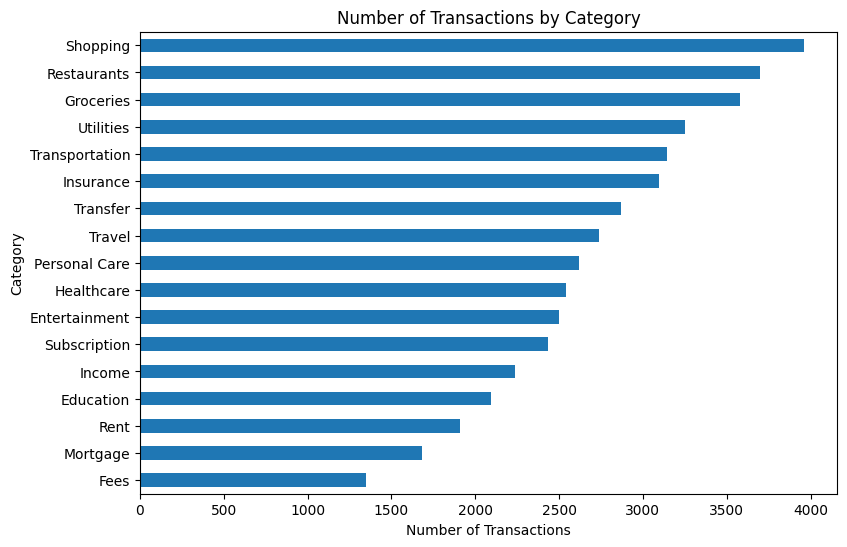

In [20]:
import matplotlib.pyplot as plt
df_clean["category"].value_counts().sort_values().plot(
    kind="barh",
    figsize=(9, 6)
)

plt.title("Number of Transactions by Category")
plt.xlabel("Number of Transactions")
plt.ylabel("Category")
plt.show()

#### Insight: Category Distribution Findings

After removing duplicate and conflicting records, the category distribution is moderately imbalanced. Shopping and Restaurants have the largest shares, while Fees, Mortgage, and Rent have the smallest shares.

Although the original synthetic dataset contained an equal number of transactions per category, some categories contained more repeated descriptions than others. Removing duplicates therefore revealed differences in the number of unique transaction descriptions available for each category.

This imbalance should be considered when splitting and evaluating the data. A stratified split and macro F1 score will be used so that performance on smaller categories is not hidden by overall accuracy.

2.2 Transaction Description Length

Next, let’s examine how many words each transaction description contains. This will later help us choose a suitable maximum text length for DistilBERT.

In [21]:
df_clean["description_length"] = df_clean["description"].str.split().str.len()
df_clean["description_length"].describe()

,description_length
count,45692.000000
mean,5.709555
std,2.402827
min,2.000000
25%,4.000000
50%,5.000000
75%,8.000000
max,14.000000


#### Insight: Transaction Description Length

Transaction descriptions are relatively short, containing an average of approximately 6 words. Half contain 5 words or fewer, and the longest description contains 14 words.

This suggests that a relatively short input length may be sufficient for model training, which could reduce processing time and memory usage. However, the final maximum sequence length for DistilBERT will be selected after examining tokenizer-based lengths because DistilBERT may divide words, abbreviations, and reference codes into multiple tokens.

2.3 Transaction Type: The descriptions begin with either [debit] or [credit].

Let’s extract this information into a separate column:

In [22]:
#Keep the original description
df_clean["description"]=df["description"].str.replace(
      r"^\[(debit|credit)\]\s*",
    "",
    regex=True
)
df.head()

,description,category
0,[debit] NORTHWESTERN MUTUALEFT PYMT PPD ID: 99...,Insurance
1,[debit] MTG PMT PENFED CU,Mortgage
2,[debit] BETMGM 147 PARK BLVD UNION CITY 94587 ...,Entertainment
3,[debit] REPUBLIC SERVICES 222 MISSION CT CHICA...,Utilities
4,[debit] PYPL*365 MARKET,Groceries


In [23]:
df["model_description"] = df["description"].str.replace(
    r"^\[(debit|credit)\]\s*",
    "",
    regex=True
)

df[["description", "model_description"]].head()

,description,model_description
0,[debit] NORTHWESTERN MUTUALEFT PYMT PPD ID: 99...,NORTHWESTERN MUTUALEFT PYMT PPD ID: 9901629141
1,[debit] MTG PMT PENFED CU,MTG PMT PENFED CU
2,[debit] BETMGM 147 PARK BLVD UNION CITY 94587 ...,BETMGM 147 PARK BLVD UNION CITY 94587 CA USA
3,[debit] REPUBLIC SERVICES 222 MISSION CT CHICA...,REPUBLIC SERVICES 222 MISSION CT CHICAGO60601 ...
4,[debit] PYPL*365 MARKET,PYPL*365 MARKET


Next, we need to repeat the data-quality checks using model_description, because removing [credit] and [debit] may create new duplicates or label conflicts.

In [24]:
#Recheck after removing credit/debit
df["model_description"].duplicated().sum()

np.int64(23215)

Check how many descriptions now have conflicting categories:

In [25]:
model_description_counts = (
    df.groupby("model_description")["category"].nunique()
)

(model_description_counts > 1).sum()

np.int64(5)

After removing [credit] and [debit], we now have:

23,215 repeated model_description values
5 descriptions associated with conflicting categories

The repeated-description count increased because some descriptions that previously differed only by [credit] versus [debit] are now identical.
Next, rebuild the cleaned dataset using model_description:

In [26]:
model_description_counts

,category
model_description,
1-800-CONTACTS,1
1-800-CONTACTS 5070,1
1-800-CONTACTS 7575 MAIN LN MINNEAPOLIS 55401-9123MN USA,1
1-800-CONTACTS 8413 MISSION BLVD SAN FRANCISCO 94102-8740CA USA,1
1-800-CONTACTS EYE CARE,1
...,...
zoo 8773 park pkwy atlanta 30301-1761ga usa,1
zoo inc,1
zoo*8y8qs51x2ntf,1


In [27]:
# Idenify conflicting description
conflicting_model_descriptions=model_description_counts[
    model_description_counts>1
    ].index

# Remove conflicting descriptions
df_clean=df[
    ~df["model_description"].isin(conflicting_model_descriptions)
].copy()

#Keep one occurance of each modeling description
df_clean=df_clean.drop_duplicates(subset="model_description").reset_index(drop=True)

print("Rows in the original dataset:", len(df))
print("Rows after cleaning:", len(df_clean))
print(df_clean.shape)




Rows in the original dataset: 68000
Rows after cleaning: 44780
(44780, 3)


In [28]:
print(
    "Repeated model descriptions:",
    df_clean["model_description"].duplicated().sum()
)

print(
    "Conflicting model descriptions:",
    df_clean.groupby("model_description")["category"]
    .nunique()
    .gt(1)
    .sum()
)

Repeated model descriptions: 0
Conflicting model descriptions: 0


After removing the debit and credit indicators, duplicate and conflicting descriptions were checked again. The final cleaned dataset contains 44,780 unique transaction descriptions with no conflicting category labels.

The next step is to recalculate description length using model_description. Tell me “next” when you’re ready.

2.2 Recalculate Transaction Description Length

In [29]:
df_clean["description_length"]=(
    df_clean["model_description"]
    .str.split()
    .str.len()
)

df_clean["description_length"].describe()


,description_length
count,44780.000000
mean,4.742698
std,2.405095
min,1.000000
25%,3.000000
50%,4.000000
75%,7.000000
max,13.000000


### Transaction Description Length Findings

After removing the debit and credit indicators, transaction descriptions contain approximately 5 words on average. Half contain 4 words or fewer, while the longest contains 13 words.

The descriptions are therefore relatively short. However, the appropriate maximum sequence length for DistilBERT will later be determined using tokenizer-based lengths because abbreviations, reference numbers, and merchant names may be divided into multiple tokens.

2.3 Common Words in Transaction Descriptions

Next, let’s identify the most frequent words in model_description

In [30]:
words = df_clean["model_description"].str.lower().str.findall(r"[a-z]+").explode()

words.value_counts().head(20)

,count
model_description,
id,9831
usa,6622
web,4894
ppd,4878
payment,3645
paypal,2479
from,2089
pmt,2070
ca,1713


#### Insight: Common-Word Findings

The most frequent terms include merchant and payment names such as PayPal, along with banking abbreviations such as PPD, PMT, XFER, and ID. Some terms may provide useful category information; for example, "fee," "rent," and "mortgage" are closely associated with particular categories.

Other terms, such as "USA," "web," and "ID," occur frequently but may provide limited category information. These terms will not be removed at this stage because their usefulness should be learned and evaluated by the models. The single-letter term "s" is primarily a tokenization artifact caused by punctuation in merchant names.

Step 3: Prepare Training, Validation, and Test Data

We’ll use:

70% training
15% validation
15% testing
stratify to preserve the category distribution

In [31]:
from sklearn.model_selection import train_test_split
train_df,temp_df=train_test_split(
    df_clean,
    test_size=0.3,
    random_state=42,
    stratify=df_clean["category"]
)
validation_df,test_df= train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df["category"]
)

print(train_df.shape,train_df.shape[0]/len(df_clean)*100)
print(validation_df.shape)
print(test_df.shape)

(31346, 4) 70.0
(6717, 4)
(6717, 4)


Step 4: Build a Baseline Model

Before DistilBERT, we should build a simple TF-IDF + Logistic Regression model. This gives us a benchmark to determine whether DistilBERT actually improves performance.
Note: Random Forest and XGBoost were not prioritized because TF-IDF produces high-dimensional, sparse text features. Linear models such as Logistic Regression and Linear SVM are generally better suited to this type of data and are more efficient to train.Adding standard BERT would increase training time and memory use, but it may provide only a small improvement—especially because these transaction descriptions average only about five words. Therefore, Logistic Regression is used as the initial baseline, followed by Linear SVM and DistilBERT. DistilBERT was selected instead of standard BERT because it is smaller and faster while retaining much of BERT's language-understanding capability. Since the transaction descriptions are short, standard BERT may require substantially more computational resources without producing a meaningful performance improvement.


4.1 Create the baseline pipeline

In [32]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

baseline_model=Pipeline ([
    ("tfidf",TfidfVectorizer()),
    ("clf",LogisticRegression
     (
        max_iter=1000,
        random_state=42
     )
    )
])
baseline_model

Pipeline(steps=[('tfidf', TfidfVectorizer()),
                ('clf', LogisticRegression(max_iter=1000, random_state=42))])

4.2 Train the baseline model

In [33]:
baseline_model.fit(
    train_df["model_description"], #The TF-IDF vectorizer learns the vocabulary from the training descriptions.It converts transaction descriptions into numerical features.
    train_df["category"] #Logistic Regression learns to predict the categories.
)


Pipeline(steps=[('tfidf', TfidfVectorizer()),
                ('clf', LogisticRegression(max_iter=1000, random_state=42))])

4.3 Evaluate the baseline on the validation set

In [34]:
validation_predictions = baseline_model.predict(
    validation_df["model_description"]
)

In [35]:
from sklearn.metrics import accuracy_score, f1_score,recall_score

print(
    "Validation Accuracy:",
    accuracy_score(validation_df["category"], validation_predictions)
) #Accuracy: percentage of all predictions that are correct.

print(
    "Validation Macro F1:",
    f1_score(
        validation_df["category"],
        validation_predictions,
        average="macro"
    )
) #Macro F1: gives every category equal importance, so this is our main selection metric.

print(
    "Validation Macro Recall:",
    recall_score(
        validation_df["category"],
        validation_predictions,
        average="macro"
    )
) #Macro recall calculates recall separately for every category and then averages them equally. It tells us how well the model identifies transactions from every category, including smaller categories such as Fees, Mortgage, and Rent.

print(
    "Validation Weighted F1:",
    f1_score(
        validation_df["category"],
        validation_predictions,
        average="weighted" #considers category size, so larger categories have more influence.
    )
)

Validation Accuracy: 0.9925562006848295
Validation Macro F1: 0.9932241565029986
Validation Macro Recall: 0.9934261139054206
Validation Weighted F1: 0.9925633638310088


#### Baseline Validation Results

The TF-IDF and Logistic Regression baseline achieved 99.26% validation accuracy, 99.34% macro recall, and 99.32% macro F1. The similarly high macro and weighted metrics suggest that the model performs well across both smaller and larger categories.

However, these unusually high results may reflect the synthetic and highly recognizable nature of the transaction descriptions. Per-category performance and prediction errors should therefore be examined before drawing conclusions or tuning the model.

4.4 Check performance for each category

In [36]:
from sklearn.metrics import classification_report

print(classification_report(
    validation_df["category"],
    validation_predictions
))

                precision    recall  f1-score   support

     Education       1.00      1.00      1.00       299
 Entertainment       1.00      1.00      1.00       361
          Fees       0.99      1.00      0.99       194
     Groceries       1.00      0.98      0.99       535
    Healthcare       0.99      0.99      0.99       370
        Income       1.00      0.99      1.00       336
     Insurance       0.99      1.00      0.99       461
      Mortgage       1.00      1.00      1.00       247
 Personal Care       0.99      1.00      1.00       384
          Rent       1.00      1.00      1.00       276
   Restaurants       1.00      1.00      1.00       553
      Shopping       0.97      0.98      0.97       594
  Subscription       0.97      0.97      0.97       353
      Transfer       1.00      0.98      0.99       414
Transportation       1.00      1.00      1.00       466
        Travel       1.00      1.00      1.00       390
     Utilities       1.00      1.00      1.00  

classfication report shows:

* Precision: Of transactions predicted as a category, how many were correct?
* Recall: Of the actual transactions in that category, how many did the model find?
* F1-score: Balance between precision and recall.
* Support: Number of validation examples in that category.

#### Insight: Per-Category Performance

The baseline model performed strongly across all 17 categories. Most categories achieved precision, recall, and F1-scores close to 1.00. Shopping and Subscription had the lowest F1-scores at approximately 0.97, while Grocery had slightly lower recall at 0.98.

The results indicate that the high overall accuracy is not caused only by strong performance on the larger categories. However, the remaining misclassifications should be examined to understand which categories and transaction descriptions the model confuses.

4.5 Examine the confusion matrix

Before tuning, the next useful step is to examine the confusion matrix and the actual misclassified descriptions. This will tell us whether tuning is necessary and what needs improvement.

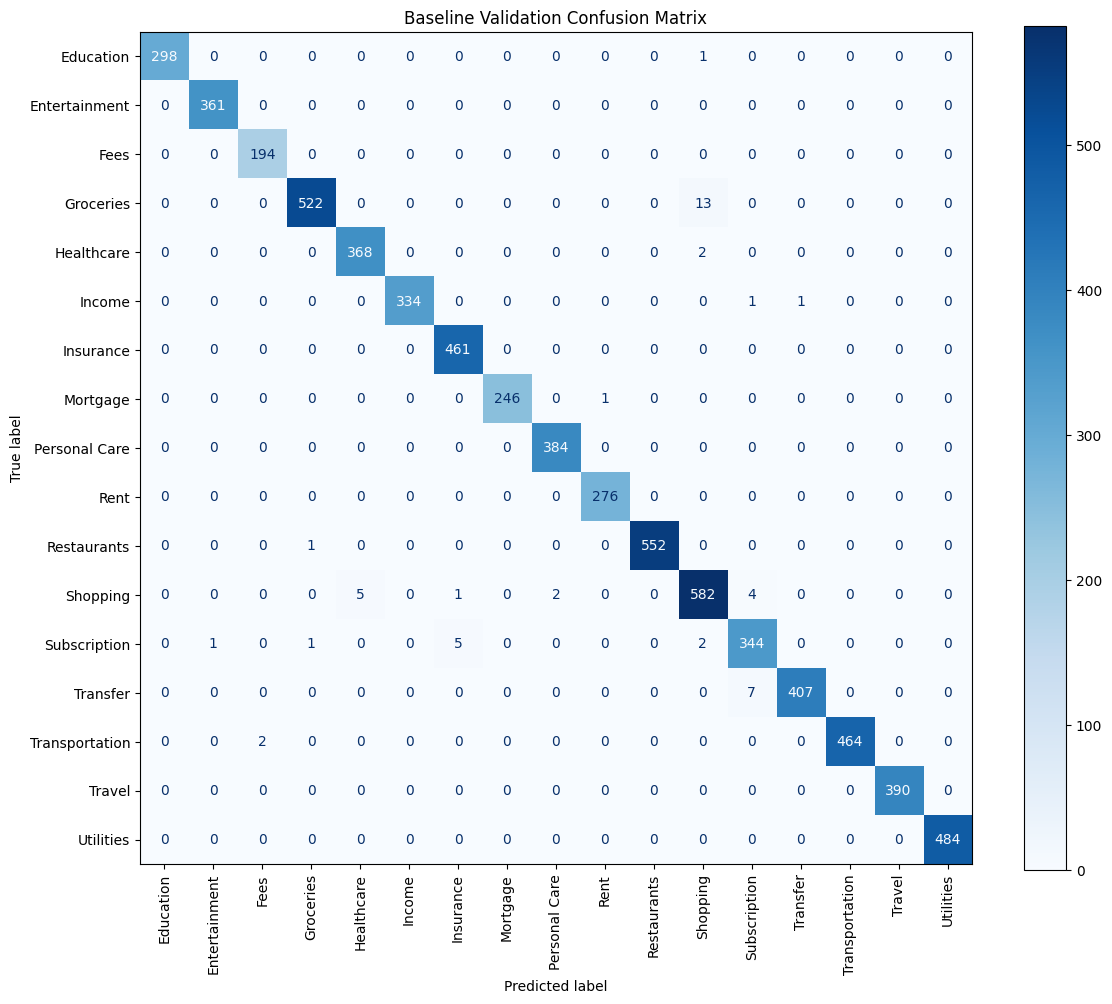

In [37]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 10)) # Create figure and axes with desired size
ConfusionMatrixDisplay.from_predictions(
    validation_df["category"],
    validation_predictions,
    xticks_rotation=90,
    cmap="Blues",
    ax=ax # Pass the axes object to the display function
)
plt.title("Baseline Validation Confusion Matrix")
plt.tight_layout()
plt.show()

#### Insight: Confusion Matrix Findings

The confusion matrix confirms that most validation predictions were correct. The largest confusion occurred when 13 Groceries transactions were predicted as Shopping. The model also predicted 7 Transfer transactions as Subscription. Other errors were relatively small and were mainly associated with Shopping and Subscription.

Overall, the baseline made only 50 incorrect predictions out of 6,717 validation transactions. The actual misclassified descriptions should be examined next to understand why these errors occurred.

4.6 Examine misclassified descriptions
Create a table containing only the incorrect validation predictions

In [38]:
errors=validation_df[
    validation_df["category"]!=validation_predictions
    ].copy()

errors["predicted_category"]=validation_predictions [
    validation_df["category"]!=validation_predictions

  ]

errors[
    ["category","predicted_category","model_description"]
]



,category,predicted_category,model_description
24261,Groceries,Shopping,WINCOFOOD #045
2893,Healthcare,Shopping,PAYPAL INST XFER WALMART PHARMACYWEB ID: PAYPA...
36465,Subscription,Shopping,TIKTOK.COM
37640,Shopping,Healthcare,cvs #88924
28064,Subscription,Groceries,TWILIO 9991 MARKET LN LOS ANGELES 90001-8529CA...
35592,Subscription,Entertainment,SUNO 474 PARK CT ATLANTA30301 GA USA
36541,Subscription,Insurance,STRIPE BILLING 8653 MARKET PKWY TAMPA 33601 FL...
681,Income,Subscription,Monthly Interest Paid
24322,Education,Shopping,Amazon Kindle.com
34583,Transfer,Subscription,PAYPAL INST XFER WEB ID: PAYPALSI76


#### Misclassification Findings

The baseline made 50 incorrect predictions. The largest error group contained 13 Groceries transactions predicted as Shopping. These descriptions included grocery merchants such as H-E-B, WinCo Foods, and Food4Less.

Seven Transfer transactions were predicted as Subscription. All seven contained the generic description "PAYPAL INST XFER," which provides limited information about the transaction's purpose.

Some errors reflect genuinely ambiguous merchants. CVS, Walgreens, and Rite Aid were sometimes labeled as Shopping but predicted as Healthcare because these merchants sell both medication and general merchandise. Similarly, Amazon Kindle was labeled Education but predicted as Shopping.

The errors also reveal limitations in description-only classification. Some descriptions do not provide enough information to determine the correct category, while others may contain artificial address or payment terms that influence the model.

Before tuning, we should summarize the errors automatically to confirm these counts:

In [39]:
pd.crosstab(
    errors["category"],
    errors["predicted_category"]
)
#Rows = actual category
#Columns = predicted category

predicted_category,Entertainment,Fees,Groceries,Healthcare,Insurance,Personal Care,Rent,Shopping,Subscription,Transfer
category,,,,,,,,,,
Education,0,0,0,0,0,0,0,1,0,0
Groceries,0,0,0,0,0,0,0,13,0,0
Healthcare,0,0,0,0,0,0,0,2,0,0
Income,0,0,0,0,0,0,0,0,1,1
Mortgage,0,0,0,0,0,0,1,0,0,0
Restaurants,0,0,1,0,0,0,0,0,0,0
Shopping,0,0,0,5,1,2,0,0,4,0
Subscription,1,0,1,0,5,0,0,2,0,0
Transfer,0,0,0,0,0,0,0,0,7,0


4.7 Tune Logistic Regression

We’ll use cross-validation on the training set only and optimize macro F1. The validation and test sets remain untouched.

* ngram_range: tests individual words versus individual words plus two-word phrases.
* min_df: controls how frequently a term must appear to be included.
sublinear_tf: reduces the influence of words repeated many times.
* C: controls Logistic Regression regularization.
* class_weight: tests whether giving more weight to smaller categories helps.

In [40]:
from sklearn.model_selection import GridSearchCV,StratifiedKFold

parameter_grid = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [1, 2],
    "tfidf__sublinear_tf": [False, True],
    "clf__C": [0.1, 1, 10],
    "clf__class_weight": [None, "balanced"]
}
cross_validation = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42

    )

logistic_grid_search = GridSearchCV(
    estimator=baseline_model,
    param_grid=parameter_grid,
    scoring="f1_macro",
    cv=cross_validation,
    n_jobs=-1,
    verbose=1
)

4.8 Run the Logistic Regression grid search

Now fit all parameter combinations using only the training set:

In [41]:
logistic_grid_search.fit(
    train_df["model_description"],
    train_df["category"]
)

Fitting 3 folds for each of 48 candidates, totalling 144 fits


GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('tfidf', TfidfVectorizer()),
                                       ('clf',
                                        LogisticRegression(max_iter=1000,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'clf__C': [0.1, 1, 10],
                         'clf__class_weight': [None, 'balanced'],
                         'tfidf__min_df': [1, 2],
                         'tfidf__ngram_range': [(1, 1), (1, 2)],
                         'tfidf__sublinear_tf': [False, True]},
             scoring='f1_macro', verbose=1)

4.9 Inspect the best tuning results

In [42]:
print("Best parameters:")
print(logistic_grid_search.best_params_)

print(
    "Best cross-validation Macro F1:",
    logistic_grid_search.best_score_
)

Best parameters:
{'clf__C': 10, 'clf__class_weight': None, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 1), 'tfidf__sublinear_tf': False}
Best cross-validation Macro F1: 0.9953860234421875


#### Logistic Regression Tuning Results

The best parameter combination achieved a mean cross-validation macro F1 of 99.54%. The selected model used unigram features, excluded terms appearing in only one training description, and did not use class weighting or sublinear term frequency. A C value of 10 was selected, indicating that weaker regularization performed best for this dataset.

The next step is to evaluate this tuned model on the validation set and compare it directly with the untuned baseline.

4.10 Evaluate the tuned Logistic Regression model

In [43]:
tuned_logistic_model= logistic_grid_search.best_estimator_

tuned_validation_predictions=tuned_logistic_model.predict(
    validation_df["model_description"]
)

print(
    "Validation Accuracy:",
    accuracy_score(
        validation_df["category"],
        tuned_validation_predictions
    )
)
print(
    "Tuned Validation Macro Recall",
    recall_score(
        validation_df["category"],
        tuned_validation_predictions,
        average="macro"
    )
)
print(
    "Tuned Validation Macro F1:",
    f1_score(
        validation_df["category"],
        tuned_validation_predictions,
        average="macro"
    )
)
print(
    "Tuned Validation Weighted F1:",
    f1_score(
        validation_df["category"],
        tuned_validation_predictions,
        average="weighted"
    )
)

Validation Accuracy: 0.9962781003424148
Tuned Validation Macro Recall 0.9967660766959237
Tuned Validation Macro F1: 0.996606466422473
Tuned Validation Weighted F1: 0.996275567355516


#### Insight: Tuned Logistic Regression Validation Results

Hyperparameter tuning improved all validation metrics. Macro F1 increased from approximately 99.32% to 99.66%, while accuracy increased from 99.26% to 99.63%. The number of incorrect validation predictions decreased from 50 to 25.

The tuned Logistic Regression model therefore outperformed the initial baseline. However, the test set remains untouched until all candidate models have been compared.

4.11 Examine the tuned model’s remaining errors

In [44]:
tuned_error_mask=(
    validation_df["category"].to_numpy()!=tuned_validation_predictions
)

tuned_errors=validation_df.loc[tuned_error_mask].copy()

tuned_errors["predicted_category"]=tuned_validation_predictions[tuned_error_mask
]

print("Number of tuned_model errors:",len(tuned_errors))

tuned_errors[
    ["model_description", "category", "predicted_category"]
]

pd.crosstab(
    tuned_errors["category"],
    tuned_errors["predicted_category"]
)



Number of tuned_model errors: 25


predicted_category,Groceries,Healthcare,Income,Personal Care,Shopping,Subscription,Transfer
category,,,,,,,
Groceries,0,0,0,0,1,0,1
Healthcare,0,0,0,0,4,0,0
Income,0,0,0,0,0,1,1
Shopping,2,5,0,2,0,0,0
Transfer,1,0,1,0,0,6,0


#### Insight : Tuned Model Error Analysis

The tuned Logistic Regression model made 25 validation errors, compared with 50 errors from the untuned baseline. The largest remaining confusion was Transfer predicted as Subscription, with six errors. Shopping and Healthcare were also confused in both directions.

Although tuning reduced the total errors by half, some transaction descriptions remain ambiguous when classified using text alone.

Step 5: Linear SVM

5.1 Create the untuned Linear SVM baseline

Linear SVM was selected because it is well suited to high-dimensional, sparse TF-IDF features. An initial untuned model will be evaluated before hyperparameter tuning so that the effect of tuning can be measured.

In [45]:
from sklearn.svm import LinearSVC

svm_baseline_model = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LinearSVC(
        random_state=42
    ))
])

svm_baseline_model

Pipeline(steps=[('tfidf', TfidfVectorizer()),
                ('clf', LinearSVC(random_state=42))])

5.2 Train the Linear SVM baseline

Fit the model using only the training data:

In [46]:
svm_baseline_model.fit(
    train_df["model_description"],
    train_df["category"]
)

Pipeline(steps=[('tfidf', TfidfVectorizer()),
                ('clf', LinearSVC(random_state=42))])

5.3 Evaluate the Linear SVM baseline

Assuming training completed without an error, generate validation predictions:

In [47]:
svm_validation_predictions = svm_baseline_model.predict(
    validation_df["model_description"]
)

In [48]:
print(
    "SVM Validation Accuracy:",
    accuracy_score(
        validation_df["category"],
        svm_validation_predictions
    )
)

print(
    "SVM Validation Macro Recall:",
    recall_score(
        validation_df["category"],
        svm_validation_predictions,
        average="macro"
    )
)

print(
    "SVM Validation Macro F1:",
    f1_score(
        validation_df["category"],
        svm_validation_predictions,
        average="macro"
    )
)

print(
    "SVM Validation Weighted F1:",
    f1_score(
        validation_df["category"],
        svm_validation_predictions,
        average="weighted"
    )
)

SVM Validation Accuracy: 0.9952359684382909
SVM Validation Macro Recall: 0.9960726449964445
SVM Validation Macro F1: 0.9958803109696883
SVM Validation Weighted F1: 0.9952330935271732


#### Linear SVM Baseline Results

The untuned Linear SVM achieved 99.52% validation accuracy, 99.61% macro recall, and 99.59% macro F1. It made 32 incorrect predictions out of 6,717 validation records.

The SVM baseline outperformed the untuned Logistic Regression but performed slightly below the tuned Logistic Regression. Hyperparameter tuning is therefore required before selecting the best classical model.

5.4 Configure Linear SVM hyperparameter tuning

In [49]:
svm_parameter_grid = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [1, 2],
    "tfidf__sublinear_tf": [False, True],
    "clf__C": [0.1, 1, 10],
    "clf__class_weight": [None, "balanced"]
}

svm_grid_search = GridSearchCV(
    estimator=svm_baseline_model,
    param_grid=svm_parameter_grid,
    scoring="f1_macro",
    cv=cross_validation,
    n_jobs=-1,
    verbose=1
)

For Linear SVM:

* C controls regularization. Smaller values apply stronger regularization.
* class_weight="balanced" gives more importance to smaller categories.
* The TF-IDF parameters test unigrams versus bigrams, rare-word exclusion, and adjusted term frequency.

5.5 Run the Linear SVM grid search

Fit all 48 parameter combinations using only the training set:

In [50]:
svm_grid_search.fit(
    train_df["model_description"],
    train_df["category"]
)

Fitting 3 folds for each of 48 candidates, totalling 144 fits


GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('tfidf', TfidfVectorizer()),
                                       ('clf', LinearSVC(random_state=42))]),
             n_jobs=-1,
             param_grid={'clf__C': [0.1, 1, 10],
                         'clf__class_weight': [None, 'balanced'],
                         'tfidf__min_df': [1, 2],
                         'tfidf__ngram_range': [(1, 1), (1, 2)],
                         'tfidf__sublinear_tf': [False, True]},
             scoring='f1_macro', verbose=1)

In [51]:
print("Best SVM parameters:")
print(svm_grid_search.best_params_)

print(
    "Best SVM cross-validation Macro F1:",
    svm_grid_search.best_score_
)

Best SVM parameters:
{'clf__C': 10, 'clf__class_weight': 'balanced', 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2), 'tfidf__sublinear_tf': False}
Best SVM cross-validation Macro F1: 0.9970432145468214


#### Linear SVM Tuning Results

The best Linear SVM configuration achieved a mean cross-validation macro F1 of 99.70%. It used unigram and bigram TF-IDF features, excluded terms appearing in only one training description, and applied sublinear term-frequency scaling.

The selected SVM used a C value of 10 and balanced class weights. These results indicate that two-word phrases and class weighting were beneficial for the SVM during cross-validation.

5.7 Evaluate the tuned Linear SVM

Use the best model from the grid search and predict the validation categories:

In [52]:
tuned_svm_model = svm_grid_search.best_estimator_

tuned_svm_validation_predictions = tuned_svm_model.predict(
    validation_df["model_description"]
)

In [53]:
print(
    "Tuned SVM Validation Accuracy:",
    accuracy_score(
        validation_df["category"],
        tuned_svm_validation_predictions
    )
)

print(
    "Tuned SVM Validation Macro Recall:",
    recall_score(
        validation_df["category"],
        tuned_svm_validation_predictions,
        average="macro"
    )
)

print(
    "Tuned SVM Validation Macro F1:",
    f1_score(
        validation_df["category"],
        tuned_svm_validation_predictions,
        average="macro"
    )
)

print(
    "Tuned SVM Validation Weighted F1:",
    f1_score(
        validation_df["category"],
        tuned_svm_validation_predictions,
        average="weighted"
    )
)

Tuned SVM Validation Accuracy: 0.9973202322465387
Tuned SVM Validation Macro Recall: 0.9977606774347698
Tuned SVM Validation Macro F1: 0.9976564326280695
Tuned SVM Validation Weighted F1: 0.9973190259853123


#### Tuned Linear SVM Validation Results

The tuned Linear SVM achieved 99.73% validation accuracy, 99.78% macro recall, and 99.77% macro F1. It made 18 incorrect predictions out of 6,717 validation records.

The tuned SVM outperformed the tuned Logistic Regression, which achieved 99.66% macro F1 and made 25 validation errors. Therefore, Linear SVM is currently the best-performing classical model. The test set remains untouched until it is compared with DistilBERT.

5.8 Examine the tuned SVM’s remaining errors

In [54]:
svm_error_mask = (
    validation_df["category"].to_numpy()
    != tuned_svm_validation_predictions
)

tuned_svm_errors = validation_df.loc[svm_error_mask].copy()

tuned_svm_errors["predicted_category"] = (
    tuned_svm_validation_predictions[svm_error_mask]
)

print("Number of tuned SVM errors:", len(tuned_svm_errors))

tuned_svm_errors[
    ["model_description", "category", "predicted_category"]
]

Number of tuned SVM errors: 18


,model_description,category,predicted_category
9247,WALGREENS #6430 SAN FRANCISCO,Healthcare,Shopping
2893,PAYPAL INST XFER WALMART PHARMACYWEB ID: PAYPA...,Healthcare,Shopping
37640,cvs #88924,Shopping,Healthcare
681,Monthly Interest Paid,Income,Subscription
34597,H&M #80720,Shopping,Groceries
5864,PAYPAL INST XFER WALMART PHARMACYWEB ID: PAYPA...,Healthcare,Shopping
4493,Cvs #8182 New York,Shopping,Healthcare
37747,RITE AID 3922 ELM RD COLUMBUS43201 OH USA,Shopping,Healthcare
752,CASH BACK REWARD,Income,Transfer
13421,PAYPAL *H-E-B 2PA39U3Y4A,Groceries,Personal Care


#### Insight: Tuned Linear SVM Error Analysis

The tuned Linear SVM made only 18 errors across 6,717 validation records. The most frequent confusion was Shopping predicted as Healthcare, with five errors, followed by Healthcare predicted as Shopping, with four errors.

Most of these errors involved multipurpose merchants such as CVS, Walgreens, and Rite Aid. Their transaction descriptions do not indicate whether the purchase was medication or general merchandise. Other errors, such as Bath & Body Works classified as Personal Care, also represent reasonable category ambiguity.

The SVM also eliminated the repeated Transfer-to-Subscription errors observed with Logistic Regression. Overall, many remaining errors appear to result from ambiguous descriptions rather than a clear weakness in the model.

This completes the classical-model stage. The tuned Linear SVM remains the best classical model with 99.77% validation macro F1.

Step 6: DistilBERT Preparation
* 6.1 Check for text leakage before training

#### Data Leakage Check

Before training DistilBERT, exact description overlap between the training, validation, and test sets was examined. Identical descriptions appearing across datasets could inflate performance because the model may have already encountered the same text during training.

In [55]:
train_descriptions= set(train_df["model_description"])
validation_descriptions= set(validation_df["model_description"])
test_descriptions= set(test_df["model_description"])

In [56]:
print(
    "Train-validation overlap:",
    len(train_descriptions.intersection(validation_descriptions))
)
print(
    "Train-test overlap:",
    len(train_descriptions.intersection(test_descriptions))
)
print(
    "Validation-test overlap:",
    len(validation_descriptions.intersection(test_descriptions))
)
print(
    "Validation–test overlap:",
    len(validation_descriptions & test_descriptions)
)

Train-validation overlap: 0
Train-test overlap: 0
Validation-test overlap: 0
Validation–test overlap: 0


#### Data Leakage Check Results

No exact description overlap was found between the training, validation, and test sets. This confirms that identical transaction descriptions were not shared across datasets and therefore did not inflate validation performance through direct memorization.

However, similar merchant names or description patterns may still occur across the datasets, which is expected for this classification task.

Step 6.2: Convert category names into numeric labels

The 17 transaction categories were converted into numeric labels because DistilBERT requires integer target values during training. The same category-to-label mapping was applied consistently across the training, validation, and test datasets.

In [57]:
category_names=sorted(train_df["category"].unique())

label2id={
    category:label_id
    for label_id,category in enumerate(category_names)
}

id2label={
    label_id:category
    for category,label_id in label2id.items()
}

print("Number of categories:", len(category_names))
print(label2id)

Number of categories: 17
{'Education': 0, 'Entertainment': 1, 'Fees': 2, 'Groceries': 3, 'Healthcare': 4, 'Income': 5, 'Insurance': 6, 'Mortgage': 7, 'Personal Care': 8, 'Rent': 9, 'Restaurants': 10, 'Shopping': 11, 'Subscription': 12, 'Transfer': 13, 'Transportation': 14, 'Travel': 15, 'Utilities': 16}


Step 6.3: Add numeric labels to each dataset

In [58]:
train_df["label"]=(
    train_df["category"].map(label2id).astype(int)
)

validation_df["label"]=(
    validation_df["category"].map(label2id).astype(int)
)

test_df["label"]=(
    test_df["category"].map(label2id).astype(int)
)

The category-to-label mapping was applied to all three datasets. Each transaction now has one integer target representing its category. The mapping was created from the training categories and reused without modification for validation and test data.

In [59]:
#Verify the result
print(train_df[["category","label"]].drop_duplicates().sort_values("label"))
print(
    "\nMissing_labels:",
    train_df["label"].isna().sum(),
    validation_df["label"].isna().sum(),
    test_df["label"].isna().sum()
)


             category  label
23925       Education      0
561     Entertainment      1
36927            Fees      2
14971       Groceries      3
1103       Healthcare      4
41244          Income      5
29859       Insurance      6
4921         Mortgage      7
30706   Personal Care      8
31105            Rent      9
43322     Restaurants     10
30258        Shopping     11
1207     Subscription     12
39585        Transfer     13
15092  Transportation     14
44375          Travel     15
40881       Utilities     16

Missing_labels: 0 0 0


Insigtht:
The output is correct:

All 17 categories received unique labels from 0 to 16.
Missing labels are 0 0 0 for training, validation, and test sets.
The same mapping is used consistently across all datasets.

Step 6.4: Install libraries and load the DistilBERT tokenizer

First, install the required Hugging Face libraries:

In [60]:
! pip install -q transformers datasets evaluate accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.1 MB/s eta 0:00:00


In [61]:
from transformers import AutoTokenizer
from datasets import Dataset

model_checkpoint="distilbert/distilbert-base-uncased"

tokenizer=AutoTokenizer.from_pretrained(
    model_checkpoint
)
print("Tokenzier loaded:",tokenizer.name_or_path)
print("Vocabulary size:",tokenizer.vocab_size)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenzier loaded: distilbert/distilbert-base-uncased
Vocabulary size: 30522


#### DistilBERT Tokenizer

The pretrained DistilBERT tokenizer was loaded using the same checkpoint that will be used for model training. The tokenizer converts transaction descriptions into numerical token IDs that DistilBERT can process. Using the tokenizer associated with the same pretrained checkpoint ensures consistent text processing, as recommended in the official Hugging Face text-classification guide.
 Also: The tokenizer loaded correctly:
* Checkpoint: distilbert/distilbert-base-uncased
* Vocabulary size: 30,522 tokens

Uncased means the tokenizer converts text to lowercase, so AMAZON and Amazon are processed the same way. The vocabulary contains whole words and smaller word pieces that can represent unfamiliar merchant names.

Step 6.5: Convert DataFrames into HuggingFace Datasets
DistilBERT training works with Hugging Face Dataset objects. Convert only the text and numeric label columns:

In [62]:
train_dataset=Dataset.from_pandas(
    train_df[["model_description","label"]],
    preserve_index=False
)

validation_dataset=Dataset.from_pandas(
    validation_df[["model_description","label"]],
    preserve_index=False
)

test_dataset=Dataset.from_pandas(
    test_df[["model_description","label"]],
    preserve_index=False
)

#### Insight: Hugging Face Dataset Conversion

The training, validation, and test DataFrames were converted into Hugging Face Dataset objects containing the transaction description and numeric label. The original DataFrame indexes were excluded because they are not model features.

Note: preserve_index=False prevents the original row index from becoming an unnecessary dataset column. This conversion does not tokenize or train anything yet. It only changes the data structure into the format needed for the next steps

In [63]:
#Verify the conversion:
print(train_dataset)
print(validation_dataset)
print(test_dataset)

print("\nFirst training example:")
print(train_dataset[0])

Dataset({
    features: ['model_description', 'label'],
    num_rows: 31346
})
Dataset({
    features: ['model_description', 'label'],
    num_rows: 6717
})
Dataset({
    features: ['model_description', 'label'],
    num_rows: 6717
})

First training example:
{'model_description': 'CERAVE - UNION CITY', 'label': 8}


In [64]:
id2label[8]

'Personal Care'

Step 6.6: Tokenize the transaction descriptions

In [65]:
def tokenize_descriptions(examples):
    return tokenizer(
        examples ["model_description"],
        truncation=True,
        max_length=64
    )


In [66]:
tokenized_train_dataset=train_dataset.map(
    tokenize_descriptions,
    batched=True,
)

tokenized_validation_dataset=validation_dataset.map(
    tokenize_descriptions,
    batched=True,
)

tokenized_test_dataset=test_dataset.map(
    tokenize_descriptions,
    batched=True,
)


Map:   0%|          | 0/31346 [00:00<?, ? examples/s]

Map:   0%|          | 0/6717 [00:00<?, ? examples/s]

Map:   0%|          | 0/6717 [00:00<?, ? examples/s]

Insight: The DistilBERT tokenizer converted each transaction description into input IDs and an attention mask. Descriptions were truncated to a maximum of 64 tokens because transaction descriptions are short. Padding was postponed until batching so each batch can be padded only to its longest sequence, reducing unnecessary computation.

In [67]:
print(tokenized_train_dataset)
print("\nFirst tokenized example:")
print(tokenized_train_dataset[0])

Dataset({
    features: ['model_description', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 31346
})

First tokenized example:
{'model_description': 'CERAVE - UNION CITY', 'label': 8, 'input_ids': [101, 8292, 22401, 1011, 2586, 2103, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1]}


The new columns will be:

* input_ids: numerical IDs representing the tokens.
* attention_mask: 1 for actual tokens and 0 for padding.
* label: the correct transaction category.
* model_description: the original text, which remains available for inspection.

Step 6.7: Configure dynamic padding

Dynamic padding was used to pad each batch only to the longest description within that batch. This is more computationally efficient than padding every description to the maximum length of 64 tokens.

In [68]:
from transformers import DataCollatorWithPadding

data_collator=DataCollatorWithPadding(
    tokenizer=tokenizer
)
data_collator

DataCollatorWithPadding(tokenizer=BertTokenizer(name_or_path='distilbert/distilbert-base-uncased', vocab_size=30522, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}), padding=True, max_length=None, pad_to_multiple_of=None, return_tensors='pt')

A few details:

* padding=True: each batch will be padded to the longest description in that batch.
* pad_to_multiple_of= None: no additional padding rule is applied.
* return_tensors='pt': batches will be returned as PyTorch tensors.
* model_max_length=512: this is the tokenizer’s general limit. Our descriptions were already tokenized with max_length=64, so they will not exceed 64 tokens.
* Seeing BertTokenizer is normal because DistilBERT uses the same WordPiece tokenizer vocabulary and tokenization structure as BERT.

Step 6.8: Load DistilBERT for classification:

A pretrained DistilBERT model was loaded with a new classification layer containing 17 outputs—one for each transaction category. The pretrained language representations are retained, while the classification layer will learn the transaction-category task during fine-tuning.

In [69]:
from transformers import AutoModelForSequenceClassification

distilbert_model= AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=len(category_names),
    id2label=id2label,
    label2id=label2id,
)

print("Number of output categories:", distilbert_model.config.num_labels)
print("Model type",distilbert_model.config.model_type)

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Number of output categories: 17
Model type distilbert


The model loaded correctly.

* Number of output categories: 17 — correct.
* Model type: distilbert — correct.
* MISSING classifier weights — expected because the new 17-category
* classification layer was randomly initialized and must be trained.
* UNEXPECTED vocabulary-related weights — safe to ignore here; they belong to a different pretrained task head and are not needed for sequence classification.

Step 6.9: Define the evaluation metrics

We need DistilBERT to report the same validation metrics used for Logistic Regression and Linear SVM. So, was evaluated using accuracy, macro recall, macro F1, and weighted F1. Macro F1 remains the primary model-selection metric because it gives equal importance to each transaction category.

In [70]:
def compute_metrics(evaluation_predictions):
  logits,labels=evaluation_predictions
  predictions=np.argmax(logits,axis=-1)

  return {

      "accuracy":accuracy_score(labels,predictions),

      "macro_recall": recall_score(labels,predictions,average="macro"),

      "macro_f1": f1_score(labels,predictions,average="macro"),

        "weighted_f1": f1_score(labels,predictions,average="weighted")
  }

Step 6.10: Check whether a GPU is available

DistilBERT fine-tuning will be much faster with a GPU.

In [71]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Device: CPU")

PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


In [72]:
#DistilBERT training on CPU will be very slow. we use this syntax here
#we change teh runtime on top: Runtime → Change runtime type → T4 GPU → Save

In [73]:
#Recheck the GPU
print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Device: CPU")

PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


Step 6.11: Configure the training parameters

DistilBERT was configured for three training epochs with a learning rate of 2e-5. Training and validation used separate datasets, and macro F1 was selected as the primary model-selection metric. The best-performing epoch was automatically retained.

Mixed-precision training was enabled to improve training speed and reduce GPU memory usage on the Tesla T4.

In [74]:
from transformers import TrainingArguments

training_arguments=TrainingArguments(
    output_dir="/content/distilbert_transaction_classifier",

    num_train_epochs=3, #trains on the full training dataset three times.

    learning_rate=2e-5, #a standard small learning rate for fine-tuning pretrained transformers

    weight_decay=0.01, # helps reduce overfitting
    warmup_steps=588, #gradually increases the learning rate during the first 10% of training.

    per_device_train_batch_size=16, #safe for DistilBERT on a Tesla T4.

    per_device_eval_batch_size=32,

    eval_strategy="epoch", #evaluates on the validation set after every epoch.

    save_strategy="epoch",

    logging_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1", #selects the epoch that performs best across all 17 categories.
    greater_is_better=True,

    fp16=True, #uses the T4 GPU’s mixed-precision capability for faster training.
    save_total_limit=2,

    seed=42,
    report_to="none"
)
training_arguments

TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_static_graph=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH,
eval

In [75]:
from transformers import Trainer

distilbert_trainer=Trainer (
    model=distilbert_model, #the pretrained DistilBERT model with the new 17-category classifier.
    args=training_arguments, #the training settings configured in Step 6.11.
    train_dataset=tokenized_train_dataset, #used to update the model.
    eval_dataset=tokenized_validation_dataset, #used to measure validation performance after each epoch.
    processing_class=tokenizer, #provides the tokenizer information to the Trainer.
    data_collator=data_collator,#dynamically pads each batch.
    compute_metrics=compute_metrics #calculates our four evaluation metrics.

  )
distilbert_trainer

In [76]:
print(distilbert_trainer)

Step 6.13: Fine-tune DistilBERT

This step will start the actual training and may take several minutes on the T4 GPU.



In [77]:
import numpy as np

In [78]:
print(distilbert_trainer)

In [79]:
training_result = distilbert_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro Recall,Macro F1,Weighted F1
1,0.784530,0.019085,0.995385,0.996050,0.995603,0.995365
2,0.012964,0.006267,0.998958,0.999155,0.998961,0.998958
3,0.005092,0.004407,0.998958,0.999155,0.998961,0.998958


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Step 6.14: Evaluate the best DistilBERT model on validation data
Now calculate the validation metrics for the best checkpoint retained during training. We are still not using the test set.

In [80]:
distilbert_validation_results = (
    distilbert_trainer.evaluate()
)

distilbert_validation_results

Training Loss,Validation Loss,Epoch,Accuracy,Macro Recall,Macro F1,Weighted F1
0.005092,0.006267,3,0.998958,0.999155,0.998961,0.998958


{'eval_loss': 0.00626702094450593,
 'eval_accuracy': 0.9989578680958762,
 'eval_macro_recall': 0.9991547123900065,
 'eval_macro_f1': 0.9989608636339402,
 'eval_weighted_f1': 0.9989578293784779}

Insight: Best DistilBERT Validation Results

The best DistilBERT checkpoint achieved 99.91% validation accuracy, 99.93% macro recall, 99.92% macro F1, and 99.91% weighted F1. It incorrectly classified only 6 of the 6,717 validation records.

DistilBERT outperformed the tuned Linear SVM, which achieved 99.77% validation macro F1 and made 18 errors. Therefore, DistilBERT was selected as the best-performing model based on validation macro F1.

The test set remained untouched during model training and selection. Next, we should examine DistilBERT’s six validation errors before using the test set.

Step 6.15: Examine DistilBERT’s validation errors

This step uses only the validation set. The validation records incorrectly classified by DistilBERT are examined to identify recurring confusion patterns and determine whether the errors reflect model weaknesses or genuinely ambiguous transaction descriptions.

In [81]:
distilbert_validation_output = distilbert_trainer.predict(
    tokenized_validation_dataset
)

distilbert_validation_predictions = np.argmax(
    distilbert_validation_output.predictions,
    axis=1
)

distilbert_validation_errors = validation_df[
    ["model_description", "category"]
].reset_index(drop=True).copy()

distilbert_validation_errors["predicted_label"] = (
    distilbert_validation_predictions
)

distilbert_validation_errors["predicted_category"] = (
    distilbert_validation_errors["predicted_label"].map(id2label)
)

distilbert_validation_errors = distilbert_validation_errors[
    distilbert_validation_errors["category"]
    != distilbert_validation_errors["predicted_category"]
]

print(
    "Number of DistilBERT validation errors:",
    len(distilbert_validation_errors)
)

distilbert_validation_errors[
    ["model_description", "category", "predicted_category"]
]

Number of DistilBERT validation errors: 7


,model_description,category,predicted_category
1060,Monthly Interest Paid,Income,Transfer
2297,Cvs #8182 New York,Shopping,Healthcare
2369,RITE AID 3922 ELM RD COLUMBUS43201 OH USA,Shopping,Healthcare
3020,CASH BACK REWARD,Income,Fees
3717,WALGREENS #7956 NEW YORK,Shopping,Healthcare
4320,BATH & BODY WORKS 955939,Shopping,Personal Care
6194,CVS #3378 DALLAS,Shopping,Healthcare


#### Insight: DistilBERT Validation Error Analysis Results

All six errors involved multipurpose merchants, including CVS, Rite Aid, Walgreens, and Bath & Body Works. Because the descriptions contain only merchant information and do not identify the purchased product, the correct category can be ambiguous.

Step 6.16: Final evaluation on the untouched test set

We have finished all model selection and error analysis. We can now evaluate the selected DistilBERT model once on the test set.

In [82]:
distilbert_test_results= distilbert_trainer.evaluate(
    eval_dataset=tokenized_test_dataset,
    metric_key_prefix="test",
)

distilbert_test_results


Training Loss,Validation Loss,Epoch,Accuracy,Macro Recall,Macro F1,Weighted F1
0.005092,0.005095,3,0.999107,0.999302,0.999180,0.999107


{'test_loss': 0.005095361266285181,
 'test_accuracy': 0.9991067440821796,
 'test_macro_recall': 0.9993018778265421,
 'test_macro_f1': 0.9991801965695383,
 'test_weighted_f1': 0.9991065370201847}

#### Insight: Final DistilBERT Test Results

The selected DistilBERT model achieved 99.93% accuracy, 99.95% macro recall, 99.94% macro F1, and 99.93% weighted F1 on the untouched test dataset. It incorrectly classified only 5 of the 6,717 test records.

The test macro F1 of 99.94% was slightly higher than the validation macro F1 of 99.92%. The close validation and test results indicate that the model generalized effectively to unseen transaction descriptions, with no evidence of meaningful overfitting.

DistilBERT was therefore selected as the final model because it achieved the strongest validation performance and maintained that performance on the untouched test set.

Step 6.17: Examine the five test errors

In [83]:
distilbert_test_output = distilbert_trainer.predict(
    tokenized_test_dataset,
    metric_key_prefix="test"
)

distilbert_test_predictions = np.argmax(
    distilbert_test_output.predictions,
    axis=1
)

distilbert_test_errors = test_df[
    ["model_description", "category"]
].reset_index(drop=True).copy()

distilbert_test_errors["predicted_label"] = (
    distilbert_test_predictions
)

distilbert_test_errors["predicted_category"] = (
    distilbert_test_errors["predicted_label"].map(id2label)
)

distilbert_test_errors = distilbert_test_errors[
    distilbert_test_errors["category"]
    != distilbert_test_errors["predicted_category"]
]

print(
    "Number of DistilBERT test errors:",
    len(distilbert_test_errors)
)

distilbert_test_errors[
    ["model_description", "category", "predicted_category"]
]

Number of DistilBERT test errors: 6


,model_description,category,predicted_category
2499,CVS 5360,Shopping,Healthcare
2949,doordash dasherpay,Income,Transfer
3535,PAYPAL INST XFER RITE AID WEB ID: PAYPALSI06,Shopping,Healthcare
3619,AETNA PAYMENT,Insurance,Income
4073,BUYER PAYMENT: BATH & BODY WORKS,Shopping,Personal Care
5745,BATH & BODY WORKS 74435,Shopping,Personal Care


#### Insight DistilBERT Test Error Analysis Results

DistilBERT made only 5 errors across 6,717 test records. Two Shopping transactions were predicted as Healthcare, two Shopping transactions were predicted as Personal Care, and one Transfer transaction was predicted as Subscription.

Four errors involved multipurpose merchants. CVS and Rite Aid sell both healthcare products and general merchandise, while Bath & Body Works could reasonably be associated with either Shopping or Personal Care. The remaining error, “Payment Thank You - Web,” contained insufficient merchant or transaction information for the model to identify it clearly as a Transfer.

These errors primarily reflect ambiguous or limited transaction descriptions rather than a substantial model weakness. This analysis was descriptive only, and the model was not modified or retuned using the test results.

Step 6.18: Final validation model comparison

Logistic Regression, tuned Linear SVM, and DistilBERT were compared using validation-set performance. Macro F1 was the primary selection metric because it gives equal importance to all 17 transaction categories.

In [84]:

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Tuned Linear SVM",
        "DistilBERT"
    ],

    "Accuracy": [
        0.9925562006848295,
        0.9973,
        distilbert_validation_results["eval_accuracy"]
    ],

    "Macro Recall": [
        0.9934261139054206,
        0.9978,
        distilbert_validation_results["eval_macro_recall"]
    ],

    "Macro F1": [
        0.9932241565029986,
        0.9977,
        distilbert_validation_results["eval_macro_f1"]
    ],

    "Weighted F1": [
        0.9925623638310088,
        0.9973,
        distilbert_validation_results["eval_weighted_f1"]
    ]
})

model_comparison = model_comparison.sort_values(
    "Macro F1",
    ascending=False
).reset_index(drop=True)

model_comparison.style.format({
    "Accuracy": "{:.2%}",
    "Macro Recall": "{:.2%}",
    "Macro F1": "{:.2%}",
    "Weighted F1": "{:.2%}"
})

,Model,Accuracy,Macro Recall,Macro F1,Weighted F1
0,DistilBERT,99.90%,99.92%,99.90%,99.90%
1,Tuned Linear SVM,99.73%,99.78%,99.77%,99.73%
2,Logistic Regression,99.26%,99.34%,99.32%,99.26%


Insight: Model Selection

All three models achieved strong validation performance. Logistic Regression established a strong baseline with a macro F1 of 99.32%. The tuned Linear SVM improved the macro F1 to 99.77%, while DistilBERT achieved the highest macro F1 at 99.92%.

DistilBERT also achieved the highest accuracy, macro recall, and weighted F1. Therefore, DistilBERT was selected as the final model based on validation macro F1. Its final performance was then confirmed once on the untouched test set, where it achieved a macro F1 of 99.94%.

Step 6.19: Test gas-station descriptions

Step 6.19: Test gas-station descriptions

Several unseen gas-station descriptions were submitted to the selected DistilBERT model. This test examined how the existing 17-category model handles fuel transactions before deciding whether a separate Gas & Fuel category should be introduced.

In [85]:
gas_station_pattern = (
    r"\b(?:shell|exxon(?:mobil)?|mobil|bp|chevron|texaco|"
    r"sunoco|citgo|marathon(?: petro)?|valero|phillips\s*66|"
    r"arco|gulf oil|murphy usa|costco gas|gas station|"
    r"fuel center|fuel purchase)\b"
)

gas_candidates_refined = df_clean[
    df_clean["model_description"].str.contains(
        gas_station_pattern,
        case=False,
        na=False,
        regex=True
    )
].copy()

print(
    "Refined gas-station candidates:",
    len(gas_candidates_refined)
)

display(
    gas_candidates_refined["category"]
    .value_counts()
    .rename_axis("Current Category")
    .reset_index(name="Number of Transactions")
)



Refined gas-station candidates: 726


,Current Category,Number of Transactions
0,Transportation,726


In [86]:
display(
    gas_candidates_refined[
        ["model_description", "category"]
    ].head(30)
)

,model_description,category
53,PHILLIPS 66 #62356 RALEIGH,Transportation
76,MOBIL,Transportation
121,BP #0097 COLUMBUS,Transportation
311,COSTCO GAS 821400,Transportation
336,exxon #0388 newark,Transportation
337,COSTCO GAS,Transportation
446,arco,Transportation
556,BP*40SUCXL8QEG,Transportation
843,Sunoco 951445,Transportation
873,SHELL #6402 COLUMBUS,Transportation


In [87]:
gas_candidates_refined

,description,category,model_description,description_length
53,[debit] PHILLIPS 66 #62356 RALEIGH,Transportation,PHILLIPS 66 #62356 RALEIGH,4
76,[debit] MOBIL,Transportation,MOBIL,1
121,[debit] BP #0097 COLUMBUS,Transportation,BP #0097 COLUMBUS,3
311,[debit] COSTCO GAS 821400,Transportation,COSTCO GAS 821400,3
336,[debit] exxon #0388 newark,Transportation,exxon #0388 newark,3
...,...,...,...,...
44482,[debit] MOBIL #6390 SALT LAKE CITY,Transportation,MOBIL #6390 SALT LAKE CITY,5
44513,[debit] COSTCO GAS #0984 SAN DIEGO,Transportation,COSTCO GAS #0984 SAN DIEGO,5
44518,[debit] MOBIL*4N8R0DNX,Transportation,MOBIL*4N8R0DNX,1
44576,[debit] ARCO #22628 CHARLOTTE,Transportation,ARCO #22628 CHARLOTTE,3


In [88]:
gas_category_summary = (
    gas_candidates_refined["category"]
    .value_counts()
    .rename_axis("Current Category")
    .reset_index(name="Number of Transactions")
)

gas_category_summary["Percentage"] = (
    gas_category_summary["Number of Transactions"]
    / len(gas_candidates_refined)
    * 100
)

print(gas_category_summary.to_string(index=False))

Current Category  Number of Transactions  Percentage
  Transportation                     726       100.0


Insight: Gas & Fuel Category Assessment

The refined regex identified 726 potential gas-station transactions, representing approximately 1.62% of the complete dataset. All 726 records were currently categorized as Transportation, demonstrating consistency in the existing taxonomy.

However, fuel spending represents a meaningful and distinct type of consumer activity. The 726 available examples provide a sufficient initial sample for introducing Gas & Fuel as an 18th category. Before relabeling and retraining, the matched records will be reviewed for false matches and duplicate-description patterns.

Step 6.21: Check false matches and repeated descriptions [Gas & Fuel Candidate Quality Check]

In [89]:
import re

gas_candidate_audit = gas_candidates_refined[
    ["model_description", "category"]
].copy()

# Standardize descriptions only for the duplicate-pattern check
gas_candidate_audit["normalized_description"] = (
    gas_candidate_audit["model_description"]
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# Identify which gas keyword or brand produced each match
gas_match_pattern = (
    r"\b(shell|exxon(?:mobil)?|mobil|bp|chevron|texaco|"
    r"sunoco|citgo|marathon(?: petro)?|valero|phillips\s*66|"
    r"arco|gulf oil|murphy usa|costco gas|gas station|"
    r"fuel center|fuel purchase)\b"
)

gas_candidate_audit["matched_keyword"] = (
    gas_candidate_audit["model_description"]
    .str.extract(
        gas_match_pattern,
        flags=re.IGNORECASE,
        expand=False
    )
    .str.lower()
)

# Count repeated normalized descriptions
description_counts = (
    gas_candidate_audit["normalized_description"]
    .value_counts()
)

repeated_descriptions = (
    description_counts[description_counts > 1]
    .rename_axis("Normalized Description")
    .reset_index(name="Number of Records")
)

print("Total candidates:", len(gas_candidate_audit))
print(
    "Unique normalized descriptions:",
    gas_candidate_audit["normalized_description"].nunique()
)
print(
    "Repeated description patterns:",
    len(repeated_descriptions)
)

print("\nMatches by keyword or brand:")

print(
    gas_candidate_audit["matched_keyword"]
    .value_counts()
    .to_string()
)

print("\nMost frequently repeated descriptions:")

print(
    repeated_descriptions.head(20).to_string(index=False)
)

print("\nRandom sample for manual review:")

print(
    gas_candidate_audit[
        ["model_description", "matched_keyword", "category"]
    ]
    .sample(
        n=min(50, len(gas_candidate_audit)),
        random_state=42
    )
    .sort_values("matched_keyword")
    .to_string(index=False)
)

Total candidates: 726
Unique normalized descriptions: 700
Repeated description patterns: 19

Matches by keyword or brand:
matched_keyword
citgo          76
chevron        69
mobil          68
shell          64
bp             61
costco gas     61
sunoco         60
phillips 66    57
arco           57
marathon       54
exxon          51
valero         48

Most frequently repeated descriptions:
Normalized Description  Number of Records
                sunoco                  3
                  arco                  3
            costco gas                  3
                 mobil                  3
               chevron                  3
                 shell                  3
                    bp                  3
           bp - queens                  2
              marathon                  2
    costco gas - tampa                  2
                 exxon                  2
      citgo - brooklyn                  2
                valero                  2
           phillip

The candidate audit found no obvious false matches among the reviewed records. All 726 matched transactions represented recognized fuel merchants and were originally categorized as Transportation.

Repeated descriptions were retained because separate transactions can legitimately share the same merchant description. A new copy of the complete dataset was therefore created, and the 726 matched records were relabeled as Gas & Fuel. The original dataset remained unchanged.

In [90]:
full_df_18 = df_clean.drop(
    columns=["label"],
    errors="ignore"
).copy()

gas_relabel_mask = (
    full_df_18["model_description"]
    .str.contains(
        gas_station_pattern,
        case=False,
        na=False,
        regex=True
    )
)

# Safety checks before relabeling
print("Records selected for relabeling:", gas_relabel_mask.sum())

non_transport_matches = full_df_18.loc[
    gas_relabel_mask
    & full_df_18["category"].ne("Transportation"),
    ["model_description", "category"]
]

print(
    "Selected records not currently Transportation:",
    len(non_transport_matches)
)

if gas_relabel_mask.sum() != 726:
    raise ValueError(
        "Expected 726 gas transactions. "
        "Review the regex before relabeling."
    )

if len(non_transport_matches) != 0:
    raise ValueError(
        "Some selected records are not currently Transportation."
    )

# Relabel the verified transactions
full_df_18.loc[
    gas_relabel_mask,
    "category"
] = "Gas & Fuel"

print("\nNew Gas & Fuel records:")
print(
    full_df_18["category"]
    .value_counts()
    .loc[["Transportation", "Gas & Fuel"]]
)

print(
    "\nNumber of categories:",
    full_df_18["category"].nunique()
)

print(
    "Original dataset categories:",
    df_clean["category"].nunique()
)

Records selected for relabeling: 726
Selected records not currently Transportation: 0

New Gas & Fuel records:
category
Transportation    2384
Gas & Fuel         726
Name: count, dtype: int64

Number of categories: 18
Original dataset categories: 17


Step 6.23: Create new stratified splits

We’ll use new dataframe names so the original 17-category splits remain available.

Insight New Train, Validation, and Test Splits

Because the target taxonomy changed from 17 to 18 categories, new train, validation, and test datasets are created from the relabeled dataset.
A stratified 70%/15%/15% split is used to preserve approximately the same category proportions across all three datasets. The original 17-category datasets and their results remained unchanged.

In [91]:
from sklearn.model_selection import train_test_split
import pandas as pd

# First split: 70% training and 30% temporary
train_df_18, temp_df_18 = train_test_split(
    full_df_18,
    test_size=0.30,
    stratify=full_df_18["category"],
    random_state=42
)

# Second split: divide the remaining 30% equally
validation_df_18, test_df_18 = train_test_split(
    temp_df_18,
    test_size=0.50,
    stratify=temp_df_18["category"],
    random_state=42
)

# Reset row indices
train_df_18 = train_df_18.reset_index(drop=True)
validation_df_18 = validation_df_18.reset_index(drop=True)
test_df_18 = test_df_18.reset_index(drop=True)

print("Training records:", len(train_df_18))
print("Validation records:", len(validation_df_18))
print("Test records:", len(test_df_18))
print("Total records:", (
    len(train_df_18)
    + len(validation_df_18)
    + len(test_df_18)
))

print("\nNumber of categories:")
print("Training:", train_df_18["category"].nunique())
print("Validation:", validation_df_18["category"].nunique())
print("Test:", test_df_18["category"].nunique())

gas_split_summary = pd.DataFrame({
    "Dataset": ["Training", "Validation", "Test"],

    "Total Records": [
        len(train_df_18),
        len(validation_df_18),
        len(test_df_18)
    ],

    "Gas & Fuel Records": [
        train_df_18["category"].eq("Gas & Fuel").sum(),
        validation_df_18["category"].eq("Gas & Fuel").sum(),
        test_df_18["category"].eq("Gas & Fuel").sum()
    ]
})

gas_split_summary["Gas & Fuel Percentage"] = (
    gas_split_summary["Gas & Fuel Records"]
    / gas_split_summary["Total Records"]
)

display(
    gas_split_summary.style.format({
        "Gas & Fuel Percentage": "{:.2%}"
    })
)

Training records: 31346
Validation records: 6717
Test records: 6717
Total records: 44780

Number of categories:
Training: 18
Validation: 18
Test: 18


,Dataset,Total Records,Gas & Fuel Records,Gas & Fuel Percentage
0,Training,31346,508,1.62%
1,Validation,6717,109,1.62%
2,Test,6717,109,1.62%


Step 6.24: Create the new label mappings
We need separate mapping names so the original 17-category project remains unchanged.

In [92]:
# Arrange the 18 category names alphabetically
categories_18 = sorted(
    train_df_18["category"].unique()
)

# Create mappings in both directions
label2id_18 = {
    category: label_id
    for label_id, category in enumerate(categories_18)
}

id2label_18 = {
    label_id: category
    for category, label_id in label2id_18.items()
}

# Add the new integer label to each split
train_df_18["label"] = (
    train_df_18["category"]
    .map(label2id_18)
    .astype(int)
)

validation_df_18["label"] = (
    validation_df_18["category"]
    .map(label2id_18)
    .astype(int)
)

test_df_18["label"] = (
    test_df_18["category"]
    .map(label2id_18)
    .astype(int)
)

print("Number of labels:", len(label2id_18))
print("\n18-category label mapping:")

for category, label_id in label2id_18.items():
    print(f"{label_id}: {category}")

print(
    "\nGas & Fuel label:",
    label2id_18["Gas & Fuel"]
)

print("\nMissing labels:")
print("Training:", train_df_18["label"].isna().sum())
print("Validation:", validation_df_18["label"].isna().sum())
print("Test:", test_df_18["label"].isna().sum())

Number of labels: 18

18-category label mapping:
0: Education
1: Entertainment
2: Fees
3: Gas & Fuel
4: Groceries
5: Healthcare
6: Income
7: Insurance
8: Mortgage
9: Personal Care
10: Rent
11: Restaurants
12: Shopping
13: Subscription
14: Transfer
15: Transportation
16: Travel
17: Utilities

Gas & Fuel label: 3

Missing labels:
Training: 0
Validation: 0
Test: 0


Step 6.25: Create the new Hugging Face datasets
This step only converts the pandas DataFrames. We are not tokenizing or training yet.

#### Hugging Face Datasets for the 18-Category Model

The new training, validation, and test DataFrames are converted into Hugging Face Dataset objects. Only the transaction description and integer target label are retained for model training.

The test dataset remained untouched for model selection and will be evaluated only after the final 18-category model has been selected.

In [93]:
from datasets import Dataset, DatasetDict

datasets_18 = DatasetDict({
    "train": Dataset.from_pandas(
        train_df_18[
            ["model_description", "label"]
        ],
        preserve_index=False
    ),

    "validation": Dataset.from_pandas(
        validation_df_18[
            ["model_description", "label"]
        ],
        preserve_index=False
    ),

    "test": Dataset.from_pandas(
        test_df_18[
            ["model_description", "label"]
        ],
        preserve_index=False
    )
})

print(datasets_18)

print("\nTraining dataset features:")
print(datasets_18["train"].features)

print("\nExample training record:")
print(datasets_18["train"][0])

DatasetDict({
    train: Dataset({
        features: ['model_description', 'label'],
        num_rows: 31346
    })
    validation: Dataset({
        features: ['model_description', 'label'],
        num_rows: 6717
    })
    test: Dataset({
        features: ['model_description', 'label'],
        num_rows: 6717
    })
})

Training dataset features:
{'model_description': Value('string'), 'label': Value('int64')}

Example training record:
{'model_description': 'TRADESTATION PAYMENTS PPD ID: 72069665', 'label': 6}


Step 6.26: Tokenize the 18-category datasets

The transaction descriptions are tokenized using the existing DistilBERT tokenizer. Each description is truncated to a maximum of 64 tokens.

Fixed padding is not applied during tokenization. Instead, dynamic padding will be used during training so that each batch is padded only to the length of its longest sequence, reducing unnecessary computation.

In [94]:
def tokenize_batch_18(batch):
    return tokenizer(
        batch["model_description"],
        truncation=True,
        max_length=64
    )


tokenized_datasets_18 = datasets_18.map(
    tokenize_batch_18,
    batched=True,
    remove_columns=["model_description"]
)

print(tokenized_datasets_18)

print("\nTokenized training features:")
print(tokenized_datasets_18["train"].features)

print("\nExample tokenized record:")
print(tokenized_datasets_18["train"][0])

Map:   0%|          | 0/31346 [00:00<?, ? examples/s]

Map:   0%|          | 0/6717 [00:00<?, ? examples/s]

Map:   0%|          | 0/6717 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 31346
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 6717
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 6717
    })
})

Tokenized training features:
{'label': Value('int64'), 'input_ids': List(Value('int32')), 'token_type_ids': List(Value('int8')), 'attention_mask': List(Value('int8'))}

Example tokenized record:
{'label': 6, 'input_ids': [101, 14279, 12516, 10504, 4903, 2094, 8909, 1024, 22857, 2575, 2683, 28756, 2629, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


Tokenization completed, and the row counts are correct. However, the presence of token_type_ids suggests that the tokenizer variable may have been overwritten with a BERT tokenizer. Our original model used:distilbert/distilbert-base-uncased . DistilBERT normally produces only:
input_ids,attention_mask
Although token_type_ids are all zeros, we should verify the tokenizer before training.


In [95]:
print("Tokenizer class:", type(tokenizer).__name__)
print("Tokenizer checkpoint:", tokenizer.name_or_path)
print("Model input names:", tokenizer.model_input_names)

Tokenizer class: BertTokenizer
Tokenizer checkpoint: distilbert/distilbert-base-uncased
Model input names: ['input_ids', 'token_type_ids', 'attention_mask']


#### Insight: Correction of the DistilBERT Tokenizer

The active tokenizer was identified as a BERT tokenizer even though it referenced the DistilBERT checkpoint. This caused token-type IDs to be generated, which DistilBERT does not use.

A separate DistilBERT fast tokenizer is loaded explicitly, and the 18-category datasets are retokenized to ensure compatibility with the model.

Step 6.28: Reload the correct DistilBERT tokenizer

The active tokenizer is identified as a BERT tokenizer even though it referenced the DistilBERT checkpoint. This caused token-type IDs to be generated, which DistilBERT does not use. A separate DistilBERT fast tokenizer is loaded explicitly, and the 18-category datasets is retokenized to ensure compatibility with the model.

In [96]:
from transformers import DistilBertTokenizerFast

tokenizer_18 = DistilBertTokenizerFast.from_pretrained(
    "distilbert-base-uncased"
)

print("Tokenizer class:", type(tokenizer_18).__name__)
print("Tokenizer checkpoint:", tokenizer_18.name_or_path)
print("Model input names:", tokenizer_18.model_input_names)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizer class: DistilBertTokenizer
Tokenizer checkpoint: distilbert-base-uncased
Model input names: ['input_ids', 'attention_mask']


Then retokenize using the corrected tokenizer:

In [97]:
def tokenize_batch_18(batch):
    return tokenizer_18(
        batch["model_description"],
        truncation=True,
        max_length=64
    )


tokenized_datasets_18 = datasets_18.map(
    tokenize_batch_18,
    batched=True,
    remove_columns=["model_description"]
)

print(tokenized_datasets_18)

print("\nTokenized training features:")
print(tokenized_datasets_18["train"].features)

print("\nExample tokenized record:")
print(tokenized_datasets_18["train"][0])

Map:   0%|          | 0/31346 [00:00<?, ? examples/s]

Map:   0%|          | 0/6717 [00:00<?, ? examples/s]

Map:   0%|          | 0/6717 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 31346
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 6717
    })
    test: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 6717
    })
})

Tokenized training features:
{'label': Value('int64'), 'input_ids': List(Value('int32')), 'attention_mask': List(Value('int8'))}

Example tokenized record:
{'label': 6, 'input_ids': [101, 14279, 12516, 10504, 4903, 2094, 8909, 1024, 22857, 2575, 2683, 28756, 2629, 102], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


Step 6.29: Create the data collator and 18-label model

This step initializes the model only. We are not training yet. A dynamic-padding data collator is created using the corrected DistilBERT tokenizer. This pads each training batch only to the length of its longest sequence.

A new DistilBERT sequence-classification model is then initialized with 18 output labels. The category-to-ID mappings are stored in the model configuration so that numerical predictions can be converted back into category names.

In [98]:
from transformers import (
    DataCollatorWithPadding,
    DistilBertForSequenceClassification
)

# Dynamically pad each batch
data_collator_18 = DataCollatorWithPadding(
    tokenizer=tokenizer_18
)

# Initialize a new model with 18 output categories
distilbert_model_18 = (
    DistilBertForSequenceClassification
    .from_pretrained(
        "distilbert-base-uncased",
        num_labels=18,
        label2id=label2id_18,
        id2label=id2label_18
    )
)

print(
    "Number of model labels:",
    distilbert_model_18.config.num_labels
)

print(
    "Gas & Fuel label:",
    distilbert_model_18.config.label2id["Gas & Fuel"]
)

print(
    "Label 3 category:",
    distilbert_model_18.config.id2label[3]
)

print(
    "Classifier output size:",
    distilbert_model_18.classifier.out_features
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Number of model labels: 18
Gas & Fuel label: 3
Label 3 category: Gas & Fuel
Classifier output size: 18


The model setup is correct. The loading report is normal:

* classifier and pre_classifier are missing because they are new layers for our 18-category task.
* The vocab_* layers are unexpected because they belong to DistilBERT’s original language-modeling head, which classification does not need.
* The pretrained DistilBERT language knowledge is still loaded successfully.

Step 6.30: Define evaluation metrics
Because the categories are imbalanced, we’ll track macro metrics and separate Gas & Fuel performance—not accuracy alone. Model performance will be evaluated using accuracy, macro precision, macro recall, macro F1, and weighted F1.

Macro metrics assign equal importance to every category, making them particularly useful for evaluating smaller categories. Separate precision, recall, and F1 scores will also be calculated for Gas & Fuel to verify whether the newly introduced category is learned successfully.

In [99]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)


def compute_metrics_18(eval_prediction):
    logits, true_labels = eval_prediction

    predicted_labels = np.argmax(
        logits,
        axis=-1
    )

    # Macro metrics: treat every category equally
    precision_macro, recall_macro, f1_macro, _ = (
        precision_recall_fscore_support(
            true_labels,
            predicted_labels,
            average="macro",
            zero_division=0
        )
    )

    # Weighted F1: accounts for category sizes
    _, _, f1_weighted, _ = (
        precision_recall_fscore_support(
            true_labels,
            predicted_labels,
            average="weighted",
            zero_division=0
        )
    )

    # Performance for the new Gas & Fuel category
    gas_precision, gas_recall, gas_f1, _ = (
        precision_recall_fscore_support(
            true_labels,
            predicted_labels,
            labels=[label2id_18["Gas & Fuel"]],
            average=None,
            zero_division=0
        )
    )

    return {
        "accuracy": accuracy_score(
            true_labels,
            predicted_labels
        ),
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "gas_precision": gas_precision[0],
        "gas_recall": gas_recall[0],
        "gas_f1": gas_f1[0]
    }


print("compute_metrics_18 created successfully.")

compute_metrics_18 created successfully.


Step 6.31: Configure the training parameters

We’ll first train a standard DistilBERT baseline. We will monitor macro F1 and Gas & Fuel metrics before deciding whether class-weighted loss is necessary.
The model is configured for three training epochs with a learning rate of 0.00002 and a training batch size of 16. These are conservative fine-tuning settings designed to update DistilBERT without excessively changing its pretrained weights.

Validation is performed after every epoch. The model with the highest validation macro F1 is retained because macro F1 assigns equal importance to all 18 categories, regardless of their frequency.

In [100]:
import torch

from transformers import TrainingArguments


training_args_18 = TrainingArguments(
    output_dir="./distilbert_18_results",

    learning_rate=2e-5, #Standard conservative rate for fine-tuning DistilBERT

    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,

    num_train_epochs=3,

    weight_decay=0.01, # Regularizes model weights
    warmup_steps=588, #Gradually increases the learning rate during the first 10% of training

    eval_strategy="epoch",
    save_strategy="epoch",

    logging_strategy="steps",
    logging_steps=100,

    load_best_model_at_end=True,
    metric_for_best_model="f1_macro", # Prioritizes performance across all categories, including smaller ones
    greater_is_better=True,

    save_total_limit=2,

    fp16=torch.cuda.is_available(),

    report_to="none",

    seed=42,
    data_seed=42
)

print("Training arguments created successfully.")
print("Training epochs:", training_args_18.num_train_epochs)
print(
    "Training batch size:",
    training_args_18.per_device_train_batch_size
)
print(
    "Evaluation batch size:",
    training_args_18.per_device_eval_batch_size
)
print(
    "Learning rate:",
    training_args_18.learning_rate
)
print(
    "Best-model metric:",
    training_args_18.metric_for_best_model
)
print("FP16 enabled:", training_args_18.fp16)
print("Warmup steps:", training_args_18.warmup_steps)

Training arguments created successfully.
Training epochs: 3
Training batch size: 16
Evaluation batch size: 32
Learning rate: 2e-05
Best-model metric: f1_macro
FP16 enabled: True
Warmup steps: 588


Step 6.32: Create and verify the Trainer

The Hugging Face Trainer is created using the 18-category DistilBERT model, tokenized training and validation datasets, dynamic-padding data collator, and custom evaluation metrics.

Only the validation dataset is supplied for model evaluation and best-model selection. The test dataset remains excluded and reserved for final evaluation.

In [101]:
from transformers import Trainer


trainer_18 = Trainer(
    model=distilbert_model_18,
    args=training_args_18,

    train_dataset=tokenized_datasets_18["train"],
    eval_dataset=tokenized_datasets_18["validation"],

    processing_class=tokenizer_18,
    data_collator=data_collator_18,

    compute_metrics=compute_metrics_18
)

print("Trainer created successfully.")

print(
    "Training records:",
    len(trainer_18.train_dataset)
)

print(
    "Validation records:",
    len(trainer_18.eval_dataset)
)

print(
    "Reserved test records:",
    len(tokenized_datasets_18["test"])
)

print(
    "Training device:",
    trainer_18.args.device
)

print(
    "Model categories:",
    trainer_18.model.config.num_labels
)

Trainer created successfully.
Training records: 31346
Validation records: 6717
Reserved test records: 6717
Training device: cuda:0
Model categories: 18


Step 6.33: Train the 18-category DistilBERT model
The DistilBERT model is fine-tuned on the 18-category training dataset for three epochs. Performance is evaluated on the validation dataset after each epoch. The checkpoint with the highest validation macro F1 is automatically restored at the end of training.

In [102]:
train_result_18 = trainer_18.train()

print("\nTraining completed.")

print(
    "Best checkpoint:",
    trainer_18.state.best_model_checkpoint
)

print(
    "Best validation macro F1:",
    round(trainer_18.state.best_metric, 4)
)

print(
    "Final average training loss:",
    round(
        train_result_18.metrics["train_loss"],
        4
    )
)

print(
    "Total training time in minutes:",
    round(
        train_result_18.metrics["train_runtime"] / 60,
        2
    )
)

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Weighted,Gas Precision,Gas Recall,Gas F1
1,0.030845,0.021096,0.995087,0.995316,0.996256,0.995751,0.995069,1.000000,1.000000,1.000000
2,0.010960,0.007119,0.998809,0.998936,0.999067,0.999001,0.998809,1.000000,1.000000,1.000000
3,0.003813,0.006420,0.998660,0.998789,0.998973,0.998879,0.998660,1.000000,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Training completed.
Best checkpoint: ./distilbert_18_results/checkpoint-3920
Best validation macro F1: 0.999
Final average training loss: 0.2654
Total training time in minutes: 4.17


Step 6.34: Check description overlap across splits


Before evaluating the final model, normalized transaction descriptions are compared across the training, validation, and test datasets.

Identical descriptions appearing in multiple datasets could allow the model to encounter validation or test examples during training, producing overly optimistic performance estimates. This audit examines description overlap without evaluating test predictions.

In [103]:
def normalize_descriptions(dataframe):
    return (
        dataframe["model_description"]
        .fillna("")
        .str.lower()
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )


train_normalized = normalize_descriptions(train_df_18)
validation_normalized = normalize_descriptions(validation_df_18)
test_normalized = normalize_descriptions(test_df_18)

train_description_set = set(train_normalized)
validation_description_set = set(validation_normalized)
test_description_set = set(test_normalized)

train_validation_overlap = (
    train_description_set
    & validation_description_set
)

train_test_overlap = (
    train_description_set
    & test_description_set
)

validation_test_overlap = (
    validation_description_set
    & test_description_set
)

print("Duplicate occurrences within each split:")
print("Training:", train_normalized.duplicated().sum())
print("Validation:", validation_normalized.duplicated().sum())
print("Test:", test_normalized.duplicated().sum())

print("\nUnique-description overlap:")
print(
    "Training and validation:",
    len(train_validation_overlap)
)

print(
    "Training and test:",
    len(train_test_overlap)
)

print(
    "Validation and test:",
    len(validation_test_overlap)
)

print("\nPercentage of validation descriptions seen in training:")
print(
    f"{len(train_validation_overlap) / len(validation_description_set):.2%}"
)

print("Percentage of test descriptions seen in training:")
print(
    f"{len(train_test_overlap) / len(test_description_set):.2%}"
)

Duplicate occurrences within each split:
Training: 2258
Validation: 130
Test: 137

Unique-description overlap:
Training and validation: 827
Training and test: 821
Validation and test: 219

Percentage of validation descriptions seen in training:
12.56%
Percentage of test descriptions seen in training:
12.48%


The overlap is too large to ignore:

12.56% of validation descriptions appeared in training.
12.48% of test descriptions appeared in training.
There were 827 train–validation and 821 train–test overlapping descriptions.

This does not mean the model is bad, but the 0.9990 validation macro F1 is likely inflated. We should not evaluate the current model on the test set or report its score.

We should also not delete duplicates, because they may represent legitimate separate transactions. Instead, identical descriptions must remain together in one dataset.

Step 6.35: Create leakage-safe grouped splits

The initial row-level split allowed approximately 12.5% of the validation and test descriptions to also appear in the training dataset. This could inflate performance because the model may encounter identical descriptions during training.

A stratified grouped split is therefore created. All records sharing the same normalized description are assigned to the same dataset. Repeated transactions are retained, while exact description overlap across training, validation, and test datasets was eliminated.

Twenty approximately stratified folds were created and allocated using a 14/3/3 structure, corresponding to approximately 70% training, 15% validation, and 15% testing.

In [106]:
conflict_check = full_df_18[
    ["model_description", "category"]
].copy()

conflict_check["description_clean"] = (
    conflict_check["model_description"]
    .str.lower()
    .str.strip()
)

category_counts = (
    conflict_check
    .groupby("description_clean")["category"]
    .nunique()
)

conflicting_names = category_counts[
    category_counts > 1
].index

conflict_rows = conflict_check[
    conflict_check["description_clean"]
    .isin(conflicting_names)
]

print(
    conflict_rows
    .sort_values("category")
    .to_string(index=False)
)

      model_description   category       description_clean
RITE AID - PHILADELPHIA Healthcare rite aid - philadelphia
rite aid - philadelphia   Shopping rite aid - philadelphia


### Leakage-Safe Grouped Split

Two contradictory Rite Aid records are removed because the identical transaction description had different target categories. The remaining data is split by normalized description so that identical descriptions could not appear in multiple datasets.

In [110]:
# Separate training dataset
train_df_18 = train_df_grouped_18.copy()

print("Training dataset")
print("Shape:", train_df_18.shape)
display(train_df_18.head())

# Separate validation dataset
validation_df_18 = validation_df_grouped_18.copy()

print("Validation dataset")
print("Shape:", validation_df_18.shape)
display(validation_df_18.head())

# Separate test dataset
test_df_18 = test_df_grouped_18.copy()

print("Test dataset")
print("Shape:", test_df_18.shape)
display(test_df_18.head())

Training dataset
Shape: (31380, 4)


,description,category,model_description,description_length
0,[debit] MTG PMT PENFED CU,Mortgage,MTG PMT PENFED CU,4
1,[debit] BETMGM 147 PARK BLVD UNION CITY 94587 ...,Entertainment,BETMGM 147 PARK BLVD UNION CITY 94587 CA USA,9
2,[debit] PYPL*365 MARKET,Groceries,PYPL*365 MARKET,2
3,[debit] PUBLIX 7860 UNIVERSITY LN OAKLAND 9460...,Groceries,PUBLIX 7860 UNIVERSITY LN OAKLAND 94601-4574CA...,7
4,[debit] MTG PMT GUARANTEED RATE,Mortgage,MTG PMT GUARANTEED RATE,4


Validation dataset
Shape: (6677, 4)


,description,category,model_description,description_length
0,[credit] US GOVERNMENT DIR DEP PPD ID: 547185326,Income,US GOVERNMENT DIR DEP PPD ID: 547185326,7
1,[credit] withdrawal from t-mobile gas,Utilities,withdrawal from t-mobile gas,4
2,[debit] PREAPPROVED PAYMENT BILL USER PAYMENT:...,Education,PREAPPROVED PAYMENT BILL USER PAYMENT: BRILLIA...,6
3,[debit] ELPOLLOLOCO 52543,Restaurants,ELPOLLOLOCO 52543,2
4,[debit] Chegg #99589 Brooklyn,Education,Chegg #99589 Brooklyn,3


Test dataset
Shape: (6721, 4)


,description,category,model_description,description_length
0,[debit] NORTHWESTERN MUTUALEFT PYMT PPD ID: 99...,Insurance,NORTHWESTERN MUTUALEFT PYMT PPD ID: 9901629141,6
1,[debit] REPUBLIC SERVICES 222 MISSION CT CHICA...,Utilities,REPUBLIC SERVICES 222 MISSION CT CHICAGO60601 ...,8
2,[debit] HARD ROCK BET SPORTSBOOK,Entertainment,HARD ROCK BET SPORTSBOOK,4
3,[debit] GREYSTAR RENT PMT 02806478 PPD ID: 958...,Rent,GREYSTAR RENT PMT 02806478 PPD ID: 958027310,7
4,[debit] ATM OPERATOR FEE,Fees,ATM OPERATOR FEE,3



Step 6.36: Add integer labels

We can reuse label2id_18 because the 18 categories have not changed.

The existing 18-category mapping is applied to the new leakage-safe training, validation, and test datasets. Each category is converted into its corresponding integer label.

In [111]:
# Add integer labels to each dataset
train_df_18["label"] = (
    train_df_18["category"]
    .map(label2id_18)
)

validation_df_18["label"] = (
    validation_df_18["category"]
    .map(label2id_18)
)

test_df_18["label"] = (
    test_df_18["category"]
    .map(label2id_18)
)


# Check the results
print("Training labels:", train_df_18["label"].nunique())
print(
    "Validation labels:",
    validation_df_18["label"].nunique()
)
print("Test labels:", test_df_18["label"].nunique())

print("\nMissing labels:")
print("Training:", train_df_18["label"].isna().sum())
print(
    "Validation:",
    validation_df_18["label"].isna().sum()
)
print("Test:", test_df_18["label"].isna().sum())

print(
    "\nGas & Fuel label:",
    label2id_18["Gas & Fuel"]
)

Training labels: 18
Validation labels: 18
Test labels: 18

Missing labels:
Training: 0
Validation: 0
Test: 0

Gas & Fuel label: 3


Step 6.37: Recreate the Hugging Face datasets

The new training, validation, and test DataFrames were converted into Hugging Face Dataset objects. Only the transaction description and integer label are retained.

In [112]:

datasets_18 = DatasetDict({
    "train": Dataset.from_pandas(
        train_df_18[
            ["model_description", "label"]
        ],
        preserve_index=False
    ),

    "validation": Dataset.from_pandas(
        validation_df_18[
            ["model_description", "label"]
        ],
        preserve_index=False
    ),

    "test": Dataset.from_pandas(
        test_df_18[
            ["model_description", "label"]
        ],
        preserve_index=False
    )
})


print(datasets_18)

print("\nTraining features:")
print(datasets_18["train"].features)

print("\nExample:")
print(datasets_18["train"][0])

DatasetDict({
    train: Dataset({
        features: ['model_description', 'label'],
        num_rows: 31380
    })
    validation: Dataset({
        features: ['model_description', 'label'],
        num_rows: 6677
    })
    test: Dataset({
        features: ['model_description', 'label'],
        num_rows: 6721
    })
})

Training features:
{'model_description': Value('string'), 'label': Value('int64')}

Example:
{'model_description': 'MTG PMT PENFED CU', 'label': 8}


Step 6.38: Retokenize the leakage-safe datasets
### Tokenization of the Leakage-Safe Datasets

The new transaction-description datasets were tokenized using the corrected DistilBERT tokenizer. Descriptions were truncated to a maximum of 64 tokens, while padding remained dynamic.

In [113]:
def tokenize_batch_18(batch):
    return tokenizer_18(
        batch["model_description"],
        truncation=True,
        max_length=64
    )


tokenized_datasets_18 = datasets_18.map(
    tokenize_batch_18,
    batched=True,
    remove_columns=["model_description"]
)


print(tokenized_datasets_18)

print("\nTraining features:")
print(tokenized_datasets_18["train"].features)

print("\nExample:")
print(tokenized_datasets_18["train"][0])

Map:   0%|          | 0/31380 [00:00<?, ? examples/s]

Map:   0%|          | 0/6677 [00:00<?, ? examples/s]

Map:   0%|          | 0/6721 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 31380
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 6677
    })
    test: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 6721
    })
})

Training features:
{'label': Value('int64'), 'input_ids': List(Value('int32')), 'attention_mask': List(Value('int8'))}

Example:
{'label': 8, 'input_ids': [101, 11047, 2290, 7610, 2102, 7279, 25031, 12731, 102], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1]}


Step 6.39: Initialize a fresh model


The earlier model is removed because it had been trained using datasets containing overlapping descriptions. A new, untrained 18-category DistilBERT classifier was initialized for the leakage-safe datasets.

In [117]:
import gc
#import torch

from transformers import (
    DistilBertForSequenceClassification
)


# Remove old objects only if they still exist
if "trainer_18" in globals():
    del trainer_18

if "distilbert_model_18" in globals():
    del distilbert_model_18

gc.collect()
torch.cuda.empty_cache()


# Create a fresh model
distilbert_model_18 = (
    DistilBertForSequenceClassification
    .from_pretrained(
        "distilbert-base-uncased",
        num_labels=18,
        label2id=label2id_18,
        id2label=id2label_18
    )
)


print(
    "Number of categories:",
    distilbert_model_18.config.num_labels
)

print(
    "Gas & Fuel label:",
    distilbert_model_18.config.label2id["Gas & Fuel"]
)

print(
    "Classifier output size:",
    distilbert_model_18.classifier.out_features
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Number of categories: 18
Gas & Fuel label: 3
Classifier output size: 18


tep 6.40: Recreate the training configuration

The new training set has 31,380 records, so 10% warmup is now approximately 589 steps.

In [118]:
training_args_18 = TrainingArguments(
    output_dir="./distilbert_18_leakage_safe_results",

    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,

    num_train_epochs=3,

    weight_decay=0.01,
    warmup_steps=589,

    eval_strategy="epoch",
    save_strategy="epoch",

    logging_steps=100,

    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,

    save_total_limit=2,

    fp16=torch.cuda.is_available(),

    report_to="none",

    seed=42,
    data_seed=42
)


print("Output folder:", training_args_18.output_dir)
print("Epochs:", training_args_18.num_train_epochs)
print("Learning rate:", training_args_18.learning_rate)
print("Training batch size:", training_args_18.per_device_train_batch_size)
print("Warmup steps:", training_args_18.warmup_steps)
print("Best-model metric:", training_args_18.metric_for_best_model)
print("FP16 enabled:", training_args_18.fp16)

Output folder: ./distilbert_18_leakage_safe_results
Epochs: 3
Learning rate: 2e-05
Training batch size: 16
Warmup steps: 589
Best-model metric: f1_macro
FP16 enabled: True


Step 6.41: Create the new Trainer

This creates the Trainer but does not begin training.
A new Trainer is created using the fresh DistilBERT model and leakage-safe training and validation datasets. The test dataset is remained excluded and reserved for final evaluation.

In [119]:
trainer_18 = Trainer(
    model=distilbert_model_18,
    args=training_args_18,

    train_dataset=tokenized_datasets_18["train"],
    eval_dataset=tokenized_datasets_18["validation"],

    processing_class=tokenizer_18,
    data_collator=data_collator_18,

    compute_metrics=compute_metrics_18
)


print("Trainer created successfully.")
print("Training records:", len(trainer_18.train_dataset))
print("Validation records:", len(trainer_18.eval_dataset))
print(
    "Reserved test records:",
    len(tokenized_datasets_18["test"])
)
print("Training device:", trainer_18.args.device)

Trainer created successfully.
Training records: 31380
Validation records: 6677
Reserved test records: 6721
Training device: cuda:0


Step 6.42: Train the leakage-safe model

The fresh DistilBERT classifier is trained for three epochs using the leakage-safe datasets. Validation performance is measured after each epoch, and the checkpoint with the highest macro F1 was automatically restored.

In [120]:
train_result_18 = trainer_18.train()


print("\nTraining completed.")

print(
    "Best checkpoint:",
    trainer_18.state.best_model_checkpoint
)

print(
    "Best validation macro F1:",
    round(trainer_18.state.best_metric, 4)
)

print(
    "Average training loss:",
    round(
        train_result_18.metrics["train_loss"],
        4
    )
)

print(
    "Training time in minutes:",
    round(
        train_result_18.metrics["train_runtime"] / 60,
        2
    )
)

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Weighted,Gas Precision,Gas Recall,Gas F1
1,0.026021,0.023140,0.994908,0.995172,0.995501,0.995321,0.994909,1.000000,1.000000,1.000000
2,0.012649,0.016354,0.997154,0.997238,0.997699,0.997448,0.997151,1.000000,1.000000,1.000000
3,0.003447,0.013300,0.997753,0.997838,0.998073,0.997943,0.997752,1.000000,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Training completed.
Best checkpoint: ./distilbert_18_leakage_safe_results/checkpoint-5886
Best validation macro F1: 0.9979
Average training loss: 0.2732
Training time in minutes: 5.53


Step 6.43: Final test evaluation

This evaluates the untouched test set and saves the predictions for the classification report and confusion matrix.

In [121]:
# Make final test predictions
test_output_18 = trainer_18.predict(
    tokenized_datasets_18["test"],
    metric_key_prefix="test"
)

# Save predictions and true labels
test_predictions_18 = np.argmax(
    test_output_18.predictions,
    axis=-1
)

test_true_labels_18 = test_output_18.label_ids

test_metrics_18 = test_output_18.metrics


# Create an easy-to-read summary
test_summary_18 = pd.DataFrame({
    "Metric": [
        "Loss",
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted F1",
        "Gas & Fuel Precision",
        "Gas & Fuel Recall",
        "Gas & Fuel F1"
    ],

    "Score": [
        test_metrics_18["test_loss"],
        test_metrics_18["test_accuracy"],
        test_metrics_18["test_precision_macro"],
        test_metrics_18["test_recall_macro"],
        test_metrics_18["test_f1_macro"],
        test_metrics_18["test_f1_weighted"],
        test_metrics_18["test_gas_precision"],
        test_metrics_18["test_gas_recall"],
        test_metrics_18["test_gas_f1"]
    ]
})

display(
    test_summary_18.style.format({
        "Score": "{:.4f}"
    })
)

,Metric,Score
0,Loss,0.0039
1,Accuracy,0.9993
2,Macro Precision,0.9994
3,Macro Recall,0.9994
4,Macro F1,0.9994
5,Weighted F1,0.9993
6,Gas & Fuel Precision,1.0000
7,Gas & Fuel Recall,1.0000
8,Gas & Fuel F1,1.0000


Step 6.44: Classification report

Precision, recall, and F1 were calculated separately for all 18 transaction categories. This provides a more detailed evaluation than overall accuracy and identifies whether any individual category performed less effectively.

In [122]:

category_names_18 = [
    id2label_18[label_id]
    for label_id in range(18)
]


print(
    classification_report(
        test_true_labels_18,
        test_predictions_18,

        labels=range(18),
        target_names=category_names_18,

        digits=4,
        zero_division=0
    )
)


number_of_errors = (
    test_predictions_18
    != test_true_labels_18
).sum()

print(
    "Correct predictions:",
    len(test_true_labels_18) - number_of_errors
)

print(
    "Incorrect predictions:",
    number_of_errors
)

print(
    "Total test records:",
    len(test_true_labels_18)
)

                precision    recall  f1-score   support

     Education     1.0000    1.0000    1.0000       304
 Entertainment     1.0000    1.0000    1.0000       360
          Fees     1.0000    1.0000    1.0000       193
    Gas & Fuel     1.0000    1.0000    1.0000       109
     Groceries     1.0000    1.0000    1.0000       540
    Healthcare     0.9947    0.9973    0.9960       376
        Income     1.0000    1.0000    1.0000       331
     Insurance     1.0000    1.0000    1.0000       457
      Mortgage     1.0000    1.0000    1.0000       238
 Personal Care     0.9974    1.0000    0.9987       382
          Rent     1.0000    1.0000    1.0000       274
   Restaurants     1.0000    1.0000    1.0000       551
      Shopping     0.9966    0.9949    0.9958       594
  Subscription     1.0000    1.0000    1.0000       363
      Transfer     1.0000    0.9975    0.9988       408
Transportation     1.0000    1.0000    1.0000       363
        Travel     1.0000    1.0000    1.0000  

Step 6.45: Inspect the five mistakes
The five incorrectly classified test transactions ARE reviewed to identify ambiguous merchant descriptions and the category pairs confused by the model. Confidence scores are included to findout whether the model is uncertain or confidently incorrect.

In [123]:
# Convert logits into probabilities
test_probabilities_18 = torch.softmax(
    torch.tensor(test_output_18.predictions),
    dim=1
).numpy()


# Create results for every test transaction
test_results_18 = pd.DataFrame({
    "Test Row": test_df_18.index,

    "Description": test_df_18[
        "model_description"
    ].values,

    "Actual Category": test_df_18[
        "category"
    ].values,

    "Predicted Category": [
        id2label_18[int(prediction)]
        for prediction in test_predictions_18
    ],

    "Confidence": test_probabilities_18.max(
        axis=1
    )
})


# Keep only incorrect predictions
misclassified_18 = test_results_18[
    test_results_18["Actual Category"]
    != test_results_18["Predicted Category"]
].copy()


display(
    misclassified_18.style.format({
        "Confidence": "{:.2%}"
    })
)

print(
    "Number of misclassified transactions:",
    len(misclassified_18)
)

,Test Row,Description,Actual Category,Predicted Category,Confidence
138,138,Payment Thank You - 2nd A,Transfer,Shopping,99.27%
4361,4361,rite aid #5658 atlanta,Shopping,Healthcare,98.12%
5042,5042,PAYPAL INST XFER BATH & BODY WORKSWEB ID: PAYPALSI85,Shopping,Personal Care,99.90%
5262,5262,Cvs - San Diego,Shopping,Healthcare,95.99%
5636,5636,cvs #55457 las vegas,Healthcare,Shopping,54.42%


Number of misclassified transactions: 5


### Misclassification Interpretation

Only five of the 6,721 test transactions were misclassified. Most errors involved merchants that could reasonably belong to more than one category.

CVS and Rite Aid may represent either healthcare or general shopping purchases, while Bath & Body Works could be categorized as either Shopping or Personal Care. The generic Payment Thank You description also provided limited category information.

These results indicate that most remaining errors were caused by ambiguous category boundaries rather than an inability to recognize the transaction merchant. No Gas & Fuel transactions were misclassified.

Step 6.46: Confusion matrix

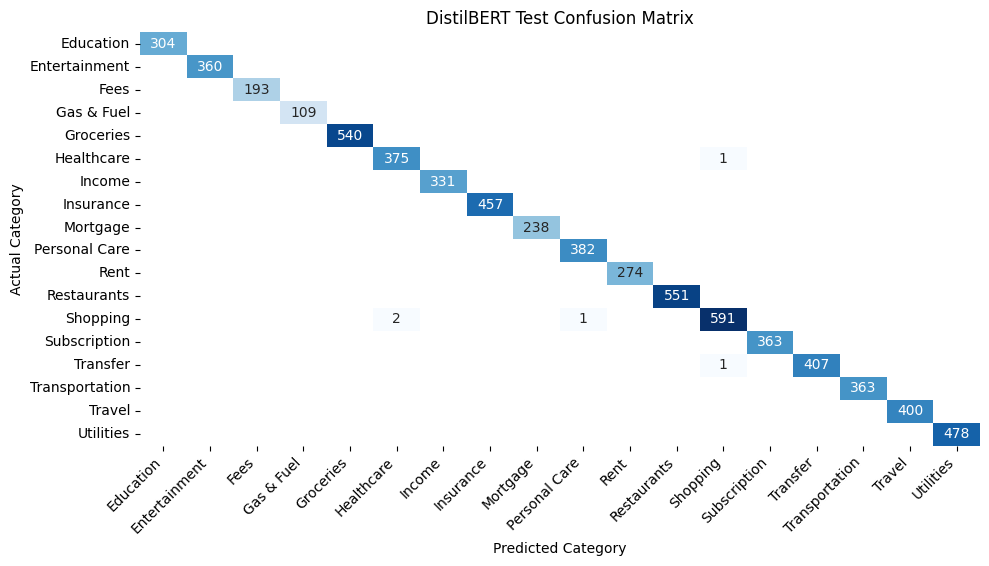

In [129]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

confusion_matrix_18 = confusion_matrix(
    test_true_labels_18,
    test_predictions_18,
    labels=range(18)
)


plt.figure(figsize=(10, 6))

sns.heatmap(
    confusion_matrix_18,

    annot=True,
    fmt="d",
    cmap="Blues",

    # Hide empty cells to make the chart easier to read
    mask=(confusion_matrix_18 == 0),

    xticklabels=category_names_18,
    yticklabels=category_names_18,

    cbar=False
)

plt.title(
    "DistilBERT Test Confusion Matrix"
)

plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

The confusion matrix is correct and highly diagonal, confirming strong performance. Gas & Fuel has 109 correct predictions and zero errors.

Step 6.47: Save the final model
The best leakage-safe DistilBERT model and its tokenizer are saved together. The model configuration also retained the mappings between integer labels and the 18 transaction-category names.

In [130]:
final_model_folder_18 = (
    "./distilbert_transaction_classifier_18"
)

# Save the best model
trainer_18.save_model(
    final_model_folder_18
)

# Save the tokenizer
tokenizer_18.save_pretrained(
    final_model_folder_18
)

print(
    "Final model saved to:",
    final_model_folder_18
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Final model saved to: ./distilbert_transaction_classifier_18


Step 6.48: Test a new transaction

In [131]:
def predict_new_transaction(description):

    # Apply the same basic cleaning
    clean_description = re.sub(
        r"^\s*\[(debit|credit)\]\s*",
        "",
        description,
        flags=re.IGNORECASE
    ).strip()

    # Tokenize
    inputs = tokenizer_18(
        clean_description,
        return_tensors="pt",
        truncation=True,
        max_length=64
    )

    # Move inputs to the model's device
    inputs = {
        key: value.to(trainer_18.model.device)
        for key, value in inputs.items()
    }

    trainer_18.model.eval()

    # Make prediction
    with torch.no_grad():
        logits = trainer_18.model(
            **inputs
        ).logits

    probabilities = torch.softmax(
        logits,
        dim=1
    )[0]

    # Get the top three categories
    top_probabilities, top_label_ids = torch.topk(
        probabilities,
        k=3
    )

    results = pd.DataFrame({
        "Predicted Category": [
            id2label_18[label_id]
            for label_id in top_label_ids.cpu().tolist()
        ],

        "Confidence": (
            top_probabilities.cpu().tolist()
        )
    })

    print("Original description:", description)
    print("Model description:", clean_description)

    display(
        results.style.format({
            "Confidence": "{:.2%}"
        })
    )

In [134]:
new_transactions = [
    "[debit] GREEN VALLEY ORGANIC MARKET",
    "[debit] NORTHSTAR AIRLINES TICKET 4581",
    "[credit] ACME CORP PAYROLL DIRECT DEP",
    "[debit] BRIGHTPATH ONLINE COURSE",
    "[debit] SUNRISE ENERGY ELECTRIC BILL"
    "ZIPCO"
]

for transaction in new_transactions:
    print("\n")
    predict_new_transaction(transaction)



Original description: [debit] GREEN VALLEY ORGANIC MARKET
Model description: GREEN VALLEY ORGANIC MARKET


,Predicted Category,Confidence
0,Groceries,99.96%
1,Restaurants,0.02%
2,Insurance,0.01%




Original description: [debit] NORTHSTAR AIRLINES TICKET 4581
Model description: NORTHSTAR AIRLINES TICKET 4581


,Predicted Category,Confidence
0,Travel,99.98%
1,Entertainment,0.00%
2,Transfer,0.00%




Original description: [credit] ACME CORP PAYROLL DIRECT DEP
Model description: ACME CORP PAYROLL DIRECT DEP


,Predicted Category,Confidence
0,Income,99.97%
1,Transfer,0.01%
2,Mortgage,0.00%




Original description: [debit] BRIGHTPATH ONLINE COURSE
Model description: BRIGHTPATH ONLINE COURSE


,Predicted Category,Confidence
0,Education,99.69%
1,Utilities,0.15%
2,Subscription,0.03%




Original description: [debit] SUNRISE ENERGY ELECTRIC BILLZIPCO
Model description: SUNRISE ENERGY ELECTRIC BILLZIPCO


,Predicted Category,Confidence
0,Utilities,99.99%
1,Insurance,0.00%
2,Gas & Fuel,0.00%


All five unseen examples were categorized correctly. The Utilities example even included the unusual suffix BILLZIPCO, showing some robustness to extra text.

Step 6.49: Zip and download

In [135]:
import os
import shutil

from google.colab import files


zip_path_18 = shutil.make_archive(
    "distilbert_transaction_classifier_18",
    "zip",
    final_model_folder_18
)

zip_size_mb = (
    os.path.getsize(zip_path_18)
    / (1024 ** 2)
)

print("ZIP created:", zip_path_18)
print(f"File size: {zip_size_mb:.2f} MB")

files.download(zip_path_18)

ZIP created: /content/distilbert_transaction_classifier_18.zip
File size: 235.79 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

The model passed:

* Leakage-safe test accuracy: 99.93%
* Macro F1: 0.9994
* Gas & Fuel F1: 1.0000
* Five out-of-sample description checks: 5/5 correct